# BÁO CÁO: PHÂN TÍCH PHÂN KHÚC KHÁCH HÀNG DỰA TRÊN DỮ LIỆU HOẠT ĐỘNG BAY
## Ứng dụng thuật toán K-Means & Decision Tree:
---
**Học phần:** Phân tích dữ liệu bằng Python | **Lớp:** MIS3041_50K29.2  
**GVHD:** Lê Diên Tuấn | **Nhóm:** 6  
**Thành viên:** Bùi Thành Anh | Nguyễn Văn Thái Bảo (Trưởng nhóm) | Thiều Anh Thư | Nguyễn Đức Khánh Toàn

---
# CHƯƠNG 3: MÔ TẢ DỮ LIỆU VÀ QUY TRÌNH TIỀN XỬ LÝ

## 3.1 & 3.2 - Đọc dữ liệu & Khám phá sơ bộ (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cài đặt hiển thị cho pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid")

# ==========================================
# ĐỌC DỮ LIỆU BAN ĐẦU
# ==========================================
print("--- ĐANG TẢI DỮ LIỆU ---")
flight_df = pd.read_csv('Customer Flight Activity.csv')
loyalty_df = pd.read_csv('Customer Loyalty History.csv')

print("\n1. Dữ liệu chuyến bay (Customer Flight Activity):")
display(flight_df.head(3))

print("\n2. Dữ liệu lịch sử khách hàng (Customer Loyalty History):")
display(loyalty_df.head(3))

--- ĐANG TẢI DỮ LIỆU ---

1. Dữ liệu chuyến bay (Customer Flight Activity):


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0



2. Dữ liệu lịch sử khách hàng (Customer Loyalty History):


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0


In [ ]:
# ==========================================
# THÔNG TIN TỔNG QUAN & DỮ LIỆU THIẾU (MỤC 3.2.2)
# ==========================================
def check_data_info(df, name):
    print(f"\n[{name}] - Kích thước: {df.shape[0]} dòng, {df.shape[1]} cột")
    missing_data = pd.DataFrame({
        'Kiểu dữ liệu': df.dtypes,
        'Số lượng Null': df.isnull().sum(),
        'Tỷ lệ Null (%)': round((df.isnull().sum() / len(df)) * 100, 2),
        'Số giá trị Unique': df.nunique()
    })
    display(missing_data.sort_values(by='Số lượng Null', ascending=False))

print("--- BẢNG THÔNG TIN TỔNG QUAN ---")
check_data_info(flight_df, "Customer Flight Activity")
check_data_info(loyalty_df, "Customer Loyalty History")

--- BẢNG THÔNG TIN TỔNG QUAN ---

[Customer Flight Activity] - Kích thước: 405624 dòng, 10 cột


,Kiểu dữ liệu,Số lượng Null,Tỷ lệ Null (%),Số giá trị Unique
Loyalty Number,int64,0,0.0,16737
Year,int64,0,0.0,2
Month,int64,0,0.0,12
Flights Booked,int64,0,0.0,22
Flights with Companions,int64,0,0.0,12
Total Flights,int64,0,0.0,33
Distance,int64,0,0.0,4746
Points Accumulated,float64,0,0.0,1549
Points Redeemed,int64,0,0.0,587
Dollar Cost Points Redeemed,int64,0,0.0,49



[Customer Loyalty History] - Kích thước: 16737 dòng, 16 cột


,Kiểu dữ liệu,Số lượng Null,Tỷ lệ Null (%),Số giá trị Unique
Cancellation Month,float64,14670,87.65,12
Cancellation Year,float64,14670,87.65,6
Salary,float64,4238,25.32,5890
Loyalty Number,int64,0,0.00,16737
City,object,0,0.00,29
Postal Code,object,0,0.00,55
Province,object,0,0.00,11
Country,object,0,0.00,1
Education,object,0,0.00,5
Gender,object,0,0.00,2


In [ ]:
# ==========================================
# THỐNG KÊ MÔ TẢ (DESCRIPTIVE STATISTICS)
# ==========================================
print("--- THỐNG KÊ MÔ TẢ CHO DỮ LIỆU SỐ ---")

print("\n[Customer Flight Activity]")
display(flight_df.describe().T.round(2))

print("\n[Customer Loyalty History - Dữ liệu số]")
display(loyalty_df.describe().T.round(2))

print("\n[Customer Loyalty History - Dữ liệu phân loại (Categorical)]")
display(loyalty_df.describe(include=['object']).T)

--- THỐNG KÊ MÔ TẢ CHO DỮ LIỆU SỐ ---

[Customer Flight Activity]


,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.87,258935.29,100018.0,326961.00,550834.0,772194.00,999986.0
Year,405624.0,2017.50,0.50,2017.0,2017.00,2017.5,2018.00,2018.0
Month,405624.0,6.50,3.45,1.0,3.75,6.5,9.25,12.0
Flights Booked,405624.0,4.12,5.23,0.0,0.00,1.0,8.00,21.0
Flights with Companions,405624.0,1.03,2.08,0.0,0.00,0.0,1.00,11.0
Total Flights,405624.0,5.15,6.52,0.0,0.00,1.0,10.00,32.0
Distance,405624.0,1208.88,1433.16,0.0,0.00,488.0,2336.00,6293.0
Points Accumulated,405624.0,123.69,146.60,0.0,0.00,50.0,239.00,676.5
Points Redeemed,405624.0,30.70,125.49,0.0,0.00,0.0,0.00,876.0
Dollar Cost Points Redeemed,405624.0,2.48,10.15,0.0,0.00,0.0,0.00,71.0



[Customer Loyalty History - Dữ liệu số]


,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.88,258912.13,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.61,35008.30,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.90,6860.98,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.25,1.98,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.67,3.40,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.50,1.38,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.96,3.46,1.00,4.00,7.00,10.00,12.00



[Customer Loyalty History - Dữ liệu phân loại (Categorical)]


,count,unique,top,freq
Country,16737,1,Canada,16737
Province,16737,11,Ontario,5404
City,16737,29,Toronto,3351
Postal Code,16737,55,V6E 3D9,911
Gender,16737,2,Female,8410
Education,16737,5,Bachelor,10475
Marital Status,16737,3,Married,9735
Loyalty Card,16737,3,Star,7637
Enrollment Type,16737,2,Standard,15766


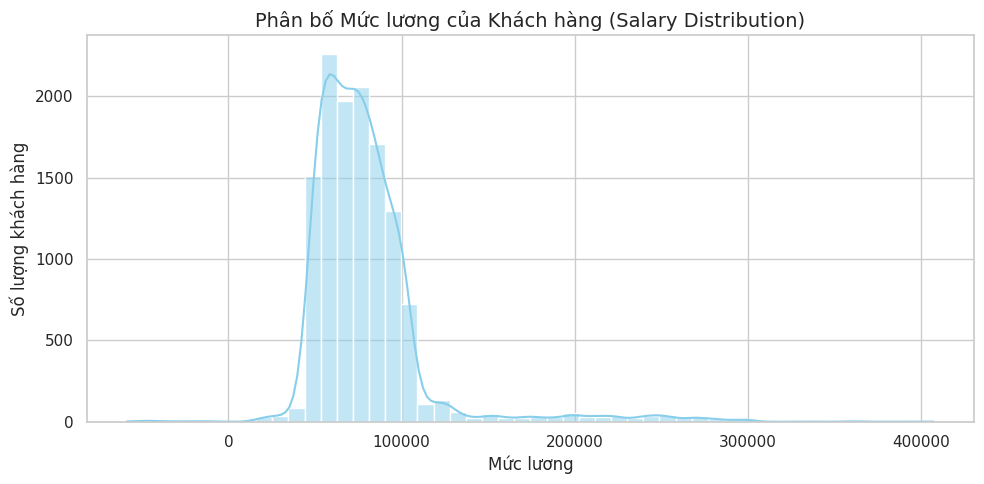

In [ ]:
# ==========================================
# EDA - BIỂU ĐỒ 1: PHÂN BỐ MỨC LƯƠNG (SALARY DISTRIBUTION)
# ==========================================
plt.figure(figsize=(10, 5))
sns.histplot(loyalty_df['Salary'].dropna(), bins=50, kde=True, color='skyblue')
plt.title('Phân bố Mức lương của Khách hàng (Salary Distribution)', fontsize=14)
plt.xlabel('Mức lương')
plt.ylabel('Số lượng khách hàng')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6663/1567011858.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loyalty_card_counts.index, y=loyalty_card_counts.values, palette='viridis')


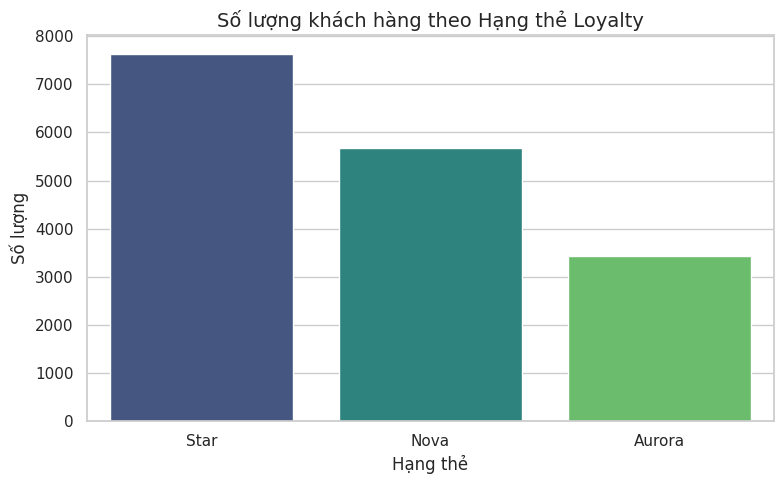

In [ ]:
# ==========================================
# EDA - BIỂU ĐỒ 2: TỶ LỆ HẠNG THẺ LOYALTY (LOYALTY CARD - BARPLOT)
# ==========================================
plt.figure(figsize=(8, 5))
loyalty_card_counts = loyalty_df['Loyalty Card'].value_counts()
sns.barplot(x=loyalty_card_counts.index, y=loyalty_card_counts.values, palette='viridis')
plt.title('Số lượng khách hàng theo Hạng thẻ Loyalty', fontsize=14)
plt.xlabel('Hạng thẻ')
plt.ylabel('Số lượng')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6663/1813256941.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=flights_by_province.values, y=flights_by_province.index, palette='magma')


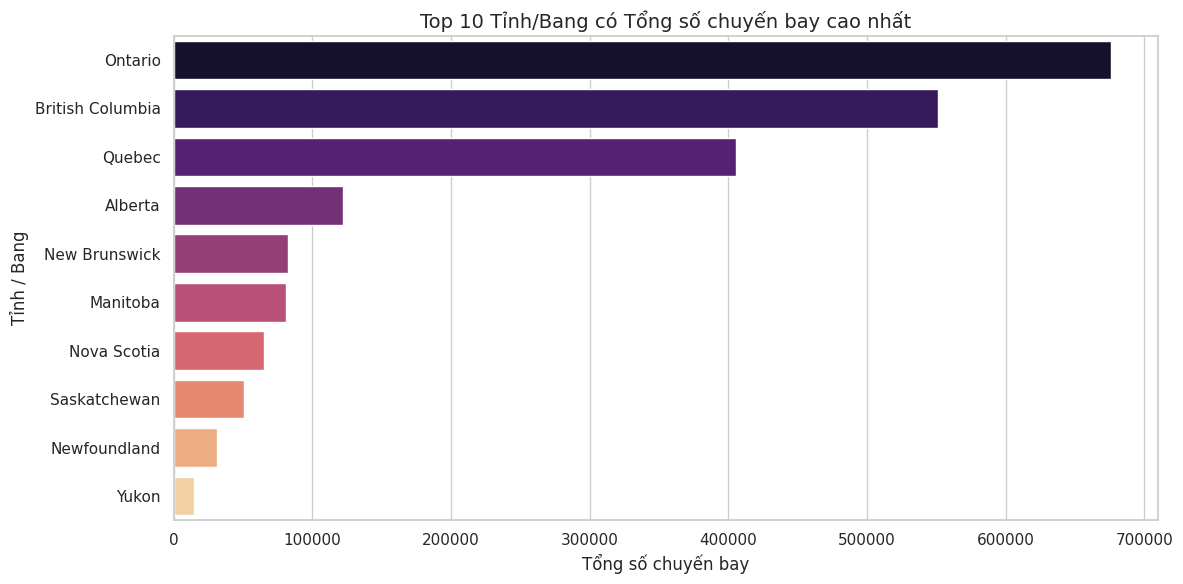

In [ ]:
# ==========================================
# EDA - BIỂU ĐỒ 3: TOP 10 TỈNH/BANG CÓ LƯU LƯỢNG BAY CAO NHẤT
# ==========================================
# Gộp tạm 2 bảng để phục vụ EDA
df_merged_eda = pd.merge(flight_df, loyalty_df, on='Loyalty Number', how='left')

plt.figure(figsize=(12, 6))
flights_by_province = df_merged_eda.groupby('Province')['Total Flights'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=flights_by_province.values, y=flights_by_province.index, palette='magma')
plt.title('Top 10 Tỉnh/Bang có Tổng số chuyến bay cao nhất', fontsize=14)
plt.xlabel('Tổng số chuyến bay')
plt.ylabel('Tỉnh / Bang')
plt.tight_layout()
plt.show()

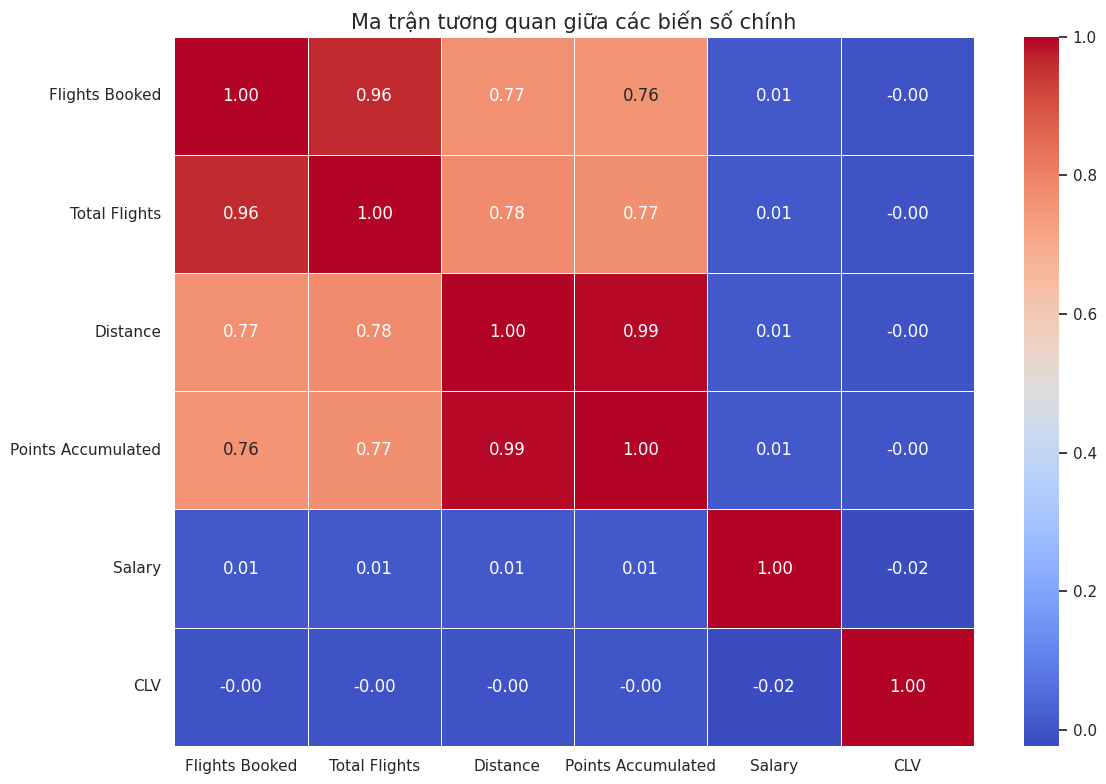

In [ ]:
# ==========================================
# EDA - BIỂU ĐỒ 4: MA TRẬN TƯƠNG QUAN DỮ LIỆU HOẠT ĐỘNG BAY (HEATMAP)
# ==========================================
plt.figure(figsize=(12, 8))
cols_to_corr = ['Flights Booked', 'Total Flights', 'Distance', 'Points Accumulated', 'Salary', 'CLV']
corr_matrix_eda = df_merged_eda[cols_to_corr].corr()
sns.heatmap(corr_matrix_eda, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số chính', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# EDA - BẢNG PHÂN TÍCH GOM NHÓM (PIVOT TABLE - BEHAVIOR ANALYSIS)
# ==========================================
print("\n--- TRUNG BÌNH CHUYẾN BAY THEO HẠNG THẺ & TÌNH TRẠNG HÔN NHÂN ---")
grouped_data = df_merged_eda.groupby(['Loyalty Card', 'Marital Status'])['Total Flights'].mean().reset_index()
pivot_data = grouped_data.pivot(index='Loyalty Card', columns='Marital Status', values='Total Flights')
display(pivot_data.round(2))


--- TRUNG BÌNH CHUYẾN BAY THEO HẠNG THẺ & TÌNH TRẠNG HÔN NHÂN ---


Marital Status,Divorced,Married,Single
Loyalty Card,,,
Aurora,5.29,5.13,5.12
Nova,4.98,5.13,5.23
Star,5.07,5.17,5.17


## 3.3 - Tiền xử lý dữ liệu

In [ ]:
# ==========================================
# 3.3.1. TỔNG HỢP DỮ LIỆU THEO KHÁCH HÀNG (GROUPBY & MERGE)
# ==========================================
# Gom nhóm dữ liệu hoạt động bay theo từng mã khách hàng và tính tổng
flight_aggregated = flight_df.groupby('Loyalty Number').agg(
    Total_Flights_Sum=('Total Flights', 'sum'),
    Total_Distance_Sum=('Distance', 'sum'),
    Total_Points_Accumulated=('Points Accumulated', 'sum'),
    Total_Points_Redeemed=('Points Redeemed', 'sum')
).reset_index()

# Hợp nhất (Inner Join) dữ liệu bay đã tổng hợp với hồ sơ khách hàng tĩnh
df_final = pd.merge(loyalty_df, flight_aggregated, on='Loyalty Number', how='inner')

print("Kích thước dữ liệu sau khi gộp:", df_final.shape)
display(df_final.head(3))

Kích thước dữ liệu sau khi gộp: (16737, 20)


,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Total_Flights_Sum,Total_Distance_Sum,Total_Points_Accumulated,Total_Points_Redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,171,51877,5224.44,1418
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,215,41578,4176.04,1971
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,87,19664,1963.00,374


In [ ]:
# ==========================================
# 3.3.2. XÂY DỰNG ĐẶC TRƯNG LRFMC (FEATURE ENGINEERING)
# ==========================================

# --- L (Length) ---
# Tuổi thọ thẻ thành viên tính đến thời điểm chốt dữ liệu (tháng 12/2018)
df_final['Enrollment_Duration_Months'] = (
    (2018 - df_final['Enrollment Year']) * 12 +
    (12 - df_final['Enrollment Month'])
)

# --- R (Recency) ---
# Số tháng kể từ chuyến bay CUỐI CÙNG tính đến tháng 12/2018
active_flights = flight_df[flight_df['Total Flights'] > 0].copy()
active_flights['Date'] = pd.to_datetime(
    active_flights['Year'].astype(str) + '-' + active_flights['Month'].astype(str) + '-01'
)
last_flight = active_flights.groupby('Loyalty Number')['Date'].max().reset_index()
last_flight.rename(columns={'Date': 'Last_Flight_Date'}, inplace=True)
df_final = pd.merge(df_final, last_flight, on='Loyalty Number', how='left')

baseline_date = pd.to_datetime('2018-12-01')
df_final['Recency_Months'] = (
    (baseline_date.year - df_final['Last_Flight_Date'].dt.year) * 12 +
    (baseline_date.month - df_final['Last_Flight_Date'].dt.month)
)
# Điền 24 tháng cho khách chưa từng bay trong giai đoạn 2017-2018
df_final['Recency_Months'] = df_final['Recency_Months'].fillna(24).astype(int)

# --- F (Frequency) & M (Monetary) ---
# Đã được tạo ở bước 3.3.1: Total_Flights_Sum, Total_Distance_Sum, Total_Points_Accumulated

# --- C (Cancellation/Cost) ---
# Is_Cancelled = 1 nếu đã hủy thẻ, = 0 nếu đang hoạt động
df_final['Is_Cancelled'] = df_final['Cancellation Year'].notnull().astype(int)

print("Kích thước dữ liệu sau Feature Engineering:", df_final.shape)
display(df_final[['Loyalty Number', 'Enrollment_Duration_Months', 'Recency_Months',
                  'Total_Flights_Sum', 'Total_Points_Accumulated', 'Is_Cancelled']].head())

Kích thước dữ liệu sau Feature Engineering: (16737, 24)


,Loyalty Number,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Points_Accumulated,Is_Cancelled
0,480934,34,0,171,5224.44,0
1,549612,33,0,215,4176.04,0
2,429460,53,11,87,1963.00,1
3,608370,70,0,159,3626.68,0
4,530508,50,0,176,3689.68,0


In [ ]:
# ==========================================
# 3.3.3. XỬ LÝ DỮ LIỆU THIẾU (MISSING VALUES)
# ==========================================
print("1. Kích thước dữ liệu ban đầu:", df_final.shape)
print("2. Số lượng missing values TRƯỚC xử lý:")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])

# Bước 1: Điền Salary bằng trung vị theo nhóm Học vấn (Education)
df_final['Salary'] = df_final.groupby('Education')['Salary'].transform(
    lambda x: x.fillna(x.median())
)
# Bước 2: Lớp bảo vệ thứ 2 - điền trung vị toàn cục cho các NaN còn sót
df_final['Salary'] = df_final['Salary'].fillna(df_final['Salary'].median())

# Loại bỏ các cột nguyên thủy không còn giá trị phân tích
cols_to_drop = ['Enrollment Year', 'Enrollment Month',
                'Cancellation Year', 'Cancellation Month', 'Last_Flight_Date']
df_final.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print("\n3. Số lượng missing values SAU xử lý:")
missing_after = df_final.isnull().sum()[df_final.isnull().sum() > 0]
print(missing_after if len(missing_after) > 0 else "-> 0 missing values. Dữ liệu sạch hoàn toàn!")

1. Kích thước dữ liệu ban đầu: (16737, 24)
2. Số lượng missing values TRƯỚC xử lý:
Salary                 4238
Cancellation Year     14670
Cancellation Month    14670
Last_Flight_Date       1501
dtype: int64

3. Số lượng missing values SAU xử lý:
-> 0 missing values. Dữ liệu sạch hoàn toàn!


1. Thống kê mô tả TRƯỚC khi capping (giá trị Max):


,Total_Flights_Sum,Total_Distance_Sum,Total_Points_Accumulated,Total_Points_Redeemed,Salary
max,448.0,101959.0,10587.5,4479.0,407228.0



2. Thống kê mô tả SAU khi capping (giá trị Max đã giảm xuống bách phân vị 95):


,Total_Flights_Sum,Total_Distance_Sum,Total_Points_Accumulated,Total_Points_Redeemed,Salary
max,213.0,49048.4,5019.55,2084.0,106669.0


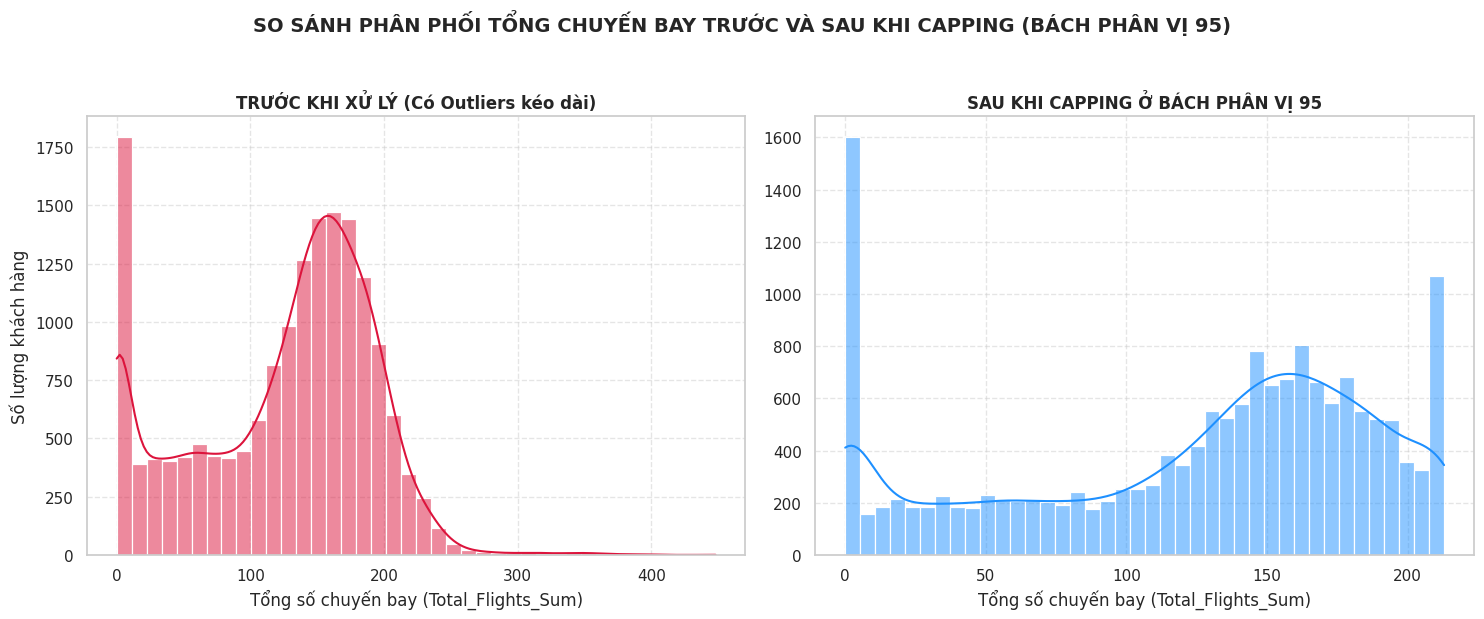

In [ ]:
# ==========================================
# 3.3.4. XỬ LÝ DỮ LIỆU NGOẠI LAI (OUTLIERS) BẰNG WINSORIZATION
# ==========================================
num_cols_to_cap = [
    'Total_Flights_Sum', 'Total_Distance_Sum',
    'Total_Points_Accumulated', 'Total_Points_Redeemed', 'Salary'
]

print("1. Thống kê mô tả TRƯỚC khi capping (giá trị Max):")
display(df_final[num_cols_to_cap].describe().loc[['max']])

flights_before_capping = df_final['Total_Flights_Sum'].copy()

# Thay thế các giá trị > bách phân vị 95 bằng chính giá trị bách phân vị 95
for col in num_cols_to_cap:
    percentile_95 = df_final[col].quantile(0.95)
    df_final[col] = np.where(df_final[col] > percentile_95, percentile_95, df_final[col])

print("\n2. Thống kê mô tả SAU khi capping (giá trị Max đã giảm xuống bách phân vị 95):")
display(df_final[num_cols_to_cap].describe().loc[['max']])

# --- Biểu đồ so sánh trước/sau ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('SO SÁNH PHÂN PHỐI TỔNG CHUYẾN BAY TRƯỚC VÀ SAU KHI CAPPING (BÁCH PHÂN VỊ 95)',
             fontsize=14, fontweight='bold', y=1.03)

sns.histplot(flights_before_capping, kde=True, color='crimson', ax=axes[0], bins=40)
axes[0].set_title('TRƯỚC KHI XỬ LÝ (Có Outliers kéo dài)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tổng số chuyến bay (Total_Flights_Sum)')
axes[0].set_ylabel('Số lượng khách hàng')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(df_final['Total_Flights_Sum'], kde=True, color='dodgerblue', ax=axes[1], bins=40)
axes[1].set_title('SAU KHI CAPPING Ở BÁCH PHÂN VỊ 95', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tổng số chuyến bay (Total_Flights_Sum)')
axes[1].set_ylabel('')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

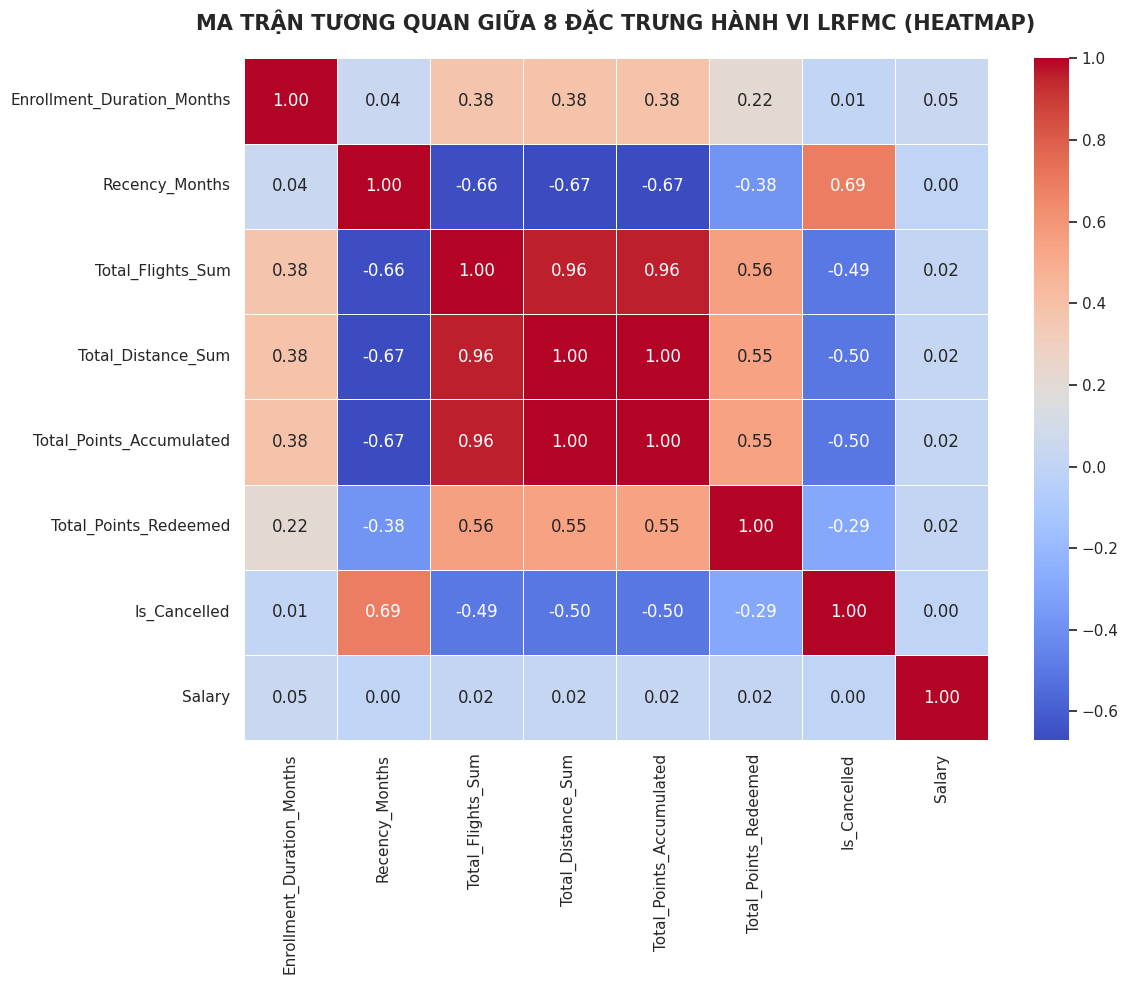

In [ ]:
# ==========================================
# 3.3.5. PHÂN TÍCH TƯƠNG QUAN ĐA BIẾN (CORRELATION ANALYSIS)
# ==========================================
cols_8_dim = [
    'Enrollment_Duration_Months', 'Recency_Months',
    'Total_Flights_Sum', 'Total_Distance_Sum',
    'Total_Points_Accumulated', 'Total_Points_Redeemed',
    'Is_Cancelled', 'Salary'
]

plt.figure(figsize=(12, 10))
corr_matrix = df_final[cols_8_dim].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('MA TRẬN TƯƠNG QUAN GIỮA 8 ĐẶC TRƯNG HÀNH VI LRFMC (HEATMAP)',
          fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 3.3.6. CHUẨN HÓA DỮ LIỆU (STANDARDIZATION / Z-SCORE SCALING)
# ==========================================
from sklearn.preprocessing import StandardScaler

features_for_clustering = [
    'Enrollment_Duration_Months', 'Recency_Months',
    'Total_Flights_Sum', 'Total_Distance_Sum',
    'Total_Points_Accumulated', 'Total_Points_Redeemed',
    'Is_Cancelled', 'Salary'
]

scaler = StandardScaler()
df_scaled_arr = scaler.fit_transform(df_final[features_for_clustering])
df_scaled = pd.DataFrame(df_scaled_arr, columns=features_for_clustering)

print("Thống kê dữ liệu sau khi chuẩn hóa (Kỳ vọng Mean ~ 0, Std ~ 1):")
display(df_scaled.describe().round(2).loc[['mean', 'std']])


Thống kê dữ liệu sau khi chuẩn hóa (Kỳ vọng Mean ~ 0, Std ~ 1):


,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Distance_Sum,Total_Points_Accumulated,Total_Points_Redeemed,Is_Cancelled,Salary
mean,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
# ==========================================
# 3.3.7. GIẢM CHIỀU DỮ LIỆU BẰNG PCA (CHỈ DÙNG ĐỂ TRỰC QUAN HÓA)
# ==========================================
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
pca_components = pca_2d.fit_transform(df_scaled)
df_pca = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

explained_variance_2d = sum(pca_2d.explained_variance_ratio_) * 100
print(f"Tỷ lệ phương sai (variance) giữ lại qua 2 thành phần PCA: {explained_variance_2d:.2f}%")
print("(Lưu ý: PCA chỉ dùng để vẽ biểu đồ, K-Means sẽ huấn luyện trên không gian 8 chiều gốc)")
display(df_pca.head())

Tỷ lệ phương sai (variance) giữ lại qua 2 thành phần PCA: 69.69%
(Lưu ý: PCA chỉ dùng để vẽ biểu đồ, K-Means sẽ huấn luyện trên không gian 8 chiều gốc)


,PCA1,PCA2
0,2.135615,0.070156
1,2.197749,-0.002976
2,-2.115997,1.886046
3,1.440339,0.845098
4,0.871697,0.353507


---
# CHƯƠNG 4: PHÂN CỤM DỮ LIỆU VÀ ĐÁNH GIÁ MÔ HÌNH K-MEANS

In [ ]:
# ==========================================
# 4.1. XÁC ĐỊNH SỐ LƯỢNG CỤM TỐI ƯU
# Kết hợp: Elbow (WCSS) + Silhouette + Davies-Bouldin + Calinski-Harabasz
# ==========================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

wcss = []
silhouette_scores = []
db_scores = []
ch_scores = []
K_range = range(2, 11)

print("Đang chạy K-Means và tính toán 4 chỉ số đánh giá. Vui lòng đợi...")

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    db_scores.append(davies_bouldin_score(df_scaled, labels))
    ch_scores.append(calinski_harabasz_score(df_scaled, labels))

print("Hoàn thành!")

Đang chạy K-Means và tính toán 4 chỉ số đánh giá. Vui lòng đợi...
Hoàn thành!


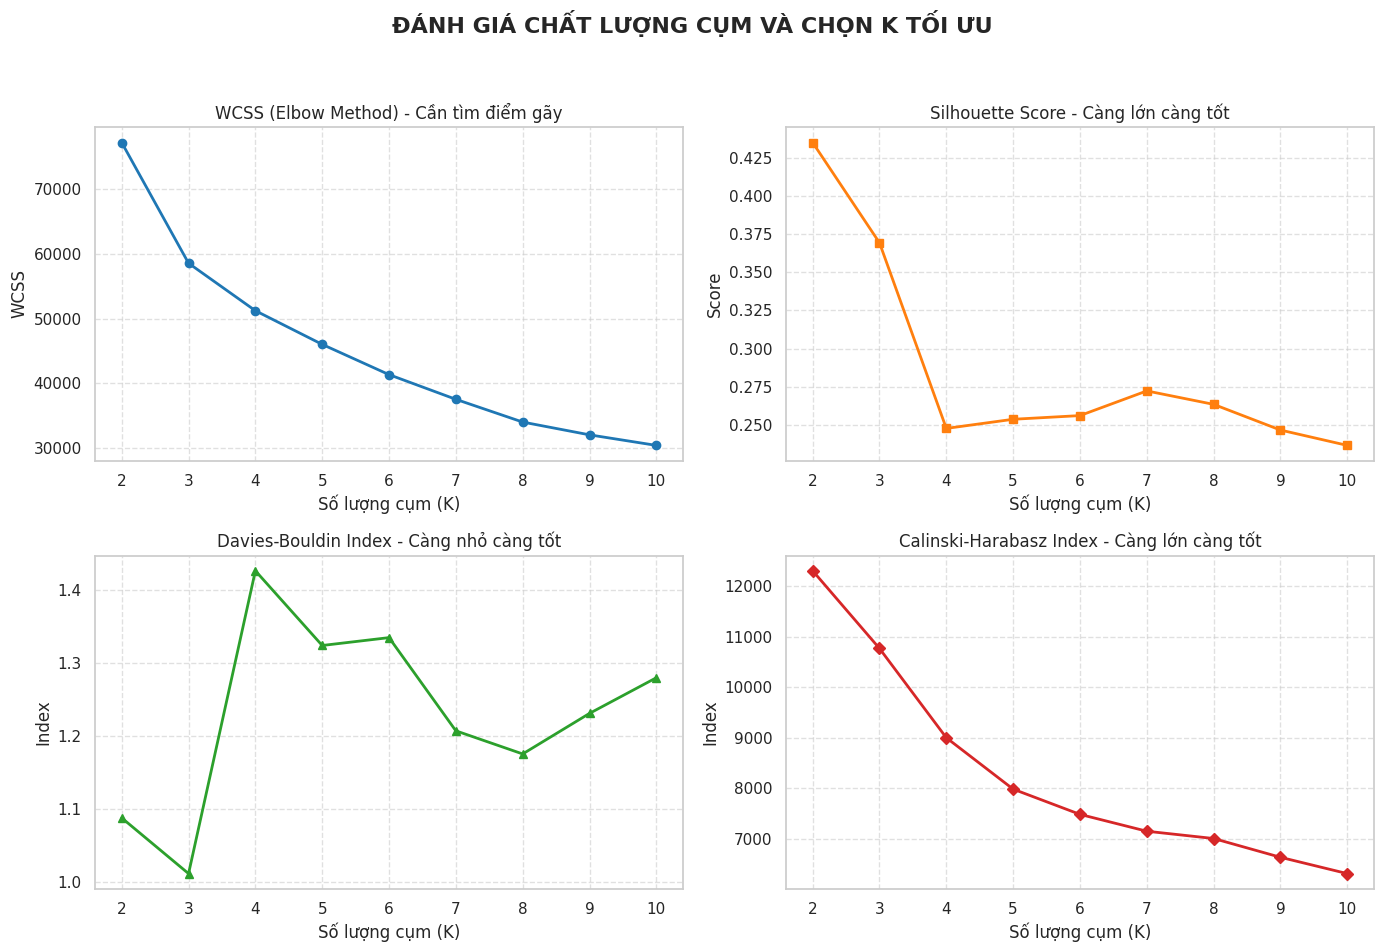


BẢNG THỐNG KÊ CHI TIẾT CÁC CHỈ SỐ (K = 2 → 10):


,Số cụm (K),WCSS (Inertia),Silhouette Score,Davies-Bouldin,Calinski-Harabasz
0,2,77166.4777,0.4350,1.0877,12302.8735
1,3,58551.9628,0.3693,1.0113,10766.5690
2,4,51225.8989,0.2477,1.4268,9001.4841
3,5,46029.5671,0.2537,1.3243,7984.9907
4,6,41362.4316,0.2561,1.3351,7485.9394
5,7,37555.9736,0.2723,1.2072,7152.7507
6,8,34046.7912,0.2635,1.1755,7008.7570
7,9,32075.7918,0.2467,1.2311,6637.6107
8,10,30447.0592,0.2366,1.2800,6314.7677


In [ ]:
# ==========================================
# 4.1.1 & 4.1.2 - VẼ DASHBOARD 4 BIỂU ĐỒ ĐÁNH GIÁ
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ĐÁNH GIÁ CHẤT LƯỢNG CỤM VÀ CHỌN K TỐI ƯU', fontsize=16, fontweight='bold')

# 1. WCSS (Elbow)
axes[0, 0].plot(K_range, wcss, marker='o', color='tab:blue', linewidth=2)
axes[0, 0].set_title('WCSS (Elbow Method) - Cần tìm điểm gãy', fontsize=12)
axes[0, 0].set_xlabel('Số lượng cụm (K)')
axes[0, 0].set_ylabel('WCSS')
axes[0, 0].grid(True, linestyle='--', alpha=0.6)
axes[0, 0].set_xticks(K_range)

# 2. Silhouette Score
axes[0, 1].plot(K_range, silhouette_scores, marker='s', color='tab:orange', linewidth=2)
axes[0, 1].set_title('Silhouette Score - Càng lớn càng tốt', fontsize=12)
axes[0, 1].set_xlabel('Số lượng cụm (K)')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(True, linestyle='--', alpha=0.6)
axes[0, 1].set_xticks(K_range)

# 3. Davies-Bouldin Index
axes[1, 0].plot(K_range, db_scores, marker='^', color='tab:green', linewidth=2)
axes[1, 0].set_title('Davies-Bouldin Index - Càng nhỏ càng tốt', fontsize=12)
axes[1, 0].set_xlabel('Số lượng cụm (K)')
axes[1, 0].set_ylabel('Index')
axes[1, 0].grid(True, linestyle='--', alpha=0.6)
axes[1, 0].set_xticks(K_range)

# 4. Calinski-Harabasz Index
axes[1, 1].plot(K_range, ch_scores, marker='D', color='tab:red', linewidth=2)
axes[1, 1].set_title('Calinski-Harabasz Index - Càng lớn càng tốt', fontsize=12)
axes[1, 1].set_xlabel('Số lượng cụm (K)')
axes[1, 1].set_ylabel('Index')
axes[1, 1].grid(True, linestyle='--', alpha=0.6)
axes[1, 1].set_xticks(K_range)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Bảng tổng hợp số liệu ---
df_metrics = pd.DataFrame({
    'Số cụm (K)': list(K_range),
    'WCSS (Inertia)': wcss,
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin': db_scores,
    'Calinski-Harabasz': ch_scores
})
print("\nBẢNG THỐNG KÊ CHI TIẾT CÁC CHỈ SỐ (K = 2 → 10):")
display(df_metrics.round(4))

In [ ]:
# ==========================================
# 4.1.3 - KẾT LUẬN CHỌN K = 3
# ==========================================
print("KẾT LUẬN CHỌN SỐ CỤM TỐI ƯU:")
print("-" * 55)
print(f"Davies-Bouldin nhỏ nhất tại K=3: {min(db_scores):.4f}")
print(f"Silhouette Score tại K=3       : {silhouette_scores[1]:.4f}")
print(f"Calinski-Harabasz tại K=3      : {ch_scores[1]:.2f}")
print("-" * 55)
print("=> Chọn K = 3 vì đạt DBI thấp nhất, Silhouette và CHI cao,")
print("   đồng thời phù hợp với mô hình CRM ngành hàng không (Trung thành / Mới / Ngủ đông).")

KẾT LUẬN CHỌN SỐ CỤM TỐI ƯU:
-------------------------------------------------------
Davies-Bouldin nhỏ nhất tại K=3: 1.0113
Silhouette Score tại K=3       : 0.3693
Calinski-Harabasz tại K=3      : 10766.57
-------------------------------------------------------
=> Chọn K = 3 vì đạt DBI thấp nhất, Silhouette và CHI cao,
   đồng thời phù hợp với mô hình CRM ngành hàng không (Trung thành / Mới / Ngủ đông).


In [ ]:
# ==========================================
# 4.2. HUẤN LUYỆN MÔ HÌNH K-MEANS VỚI K = 3
# ==========================================
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_final.fit(df_scaled)

# Gán nhãn phân khúc ngược lại vào tập dữ liệu gốc
df_final['Cluster'] = kmeans_final.labels_

print(f"Thuật toán K-Means hội tụ sau {kmeans_final.n_iter_} vòng lặp.")
print("\nSỐ LƯỢNG KHÁCH HÀNG PHÂN BỔ VÀO TỪNG CỤM:")
print("-" * 45)
cluster_counts = df_final['Cluster'].value_counts().sort_index()
for cluster_num, count in cluster_counts.items():
    percentage = (count / len(df_final)) * 100
    print(f"  Cụm {cluster_num}: {count:,} khách hàng ({percentage:.2f}%)")
print("-" * 45)

Thuật toán K-Means hội tụ sau 6 vòng lặp.

SỐ LƯỢNG KHÁCH HÀNG PHÂN BỔ VÀO TỪNG CỤM:
---------------------------------------------
  Cụm 0: 10,923 khách hàng (65.26%)
  Cụm 1: 2,360 khách hàng (14.10%)
  Cụm 2: 3,454 khách hàng (20.64%)
---------------------------------------------


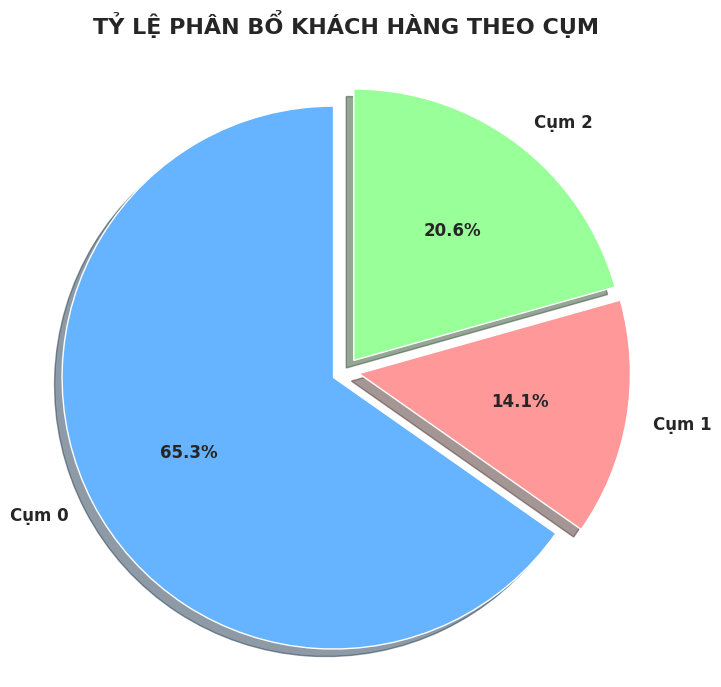

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# VẼ BIỂU ĐỒ HÌNH TRÒN (PIE CHART) MINH HỌA TỶ LỆ PHẦN TRĂM CỤM
# ==========================================
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999', '#99ff99'] # Custom colors for the pie chart
explode = [0.05] * len(cluster_counts) # Explode slices slightly for emphasis

plt.pie(cluster_counts,
        labels=[f'Cụm {i}' for i in cluster_counts.index],
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        shadow=True,
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('TỶ LỆ PHÂN BỔ KHÁCH HÀNG THEO CỤM', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# ==========================================
# 4.2.2 - IN TỌA ĐỘ TÂM CỤM VÀ XEM MẪU KHÁCH HÀNG TỪNG CỤM
# ==========================================

# Tọa độ tâm cụm trên không gian 8 chiều gốc
print("TỌA ĐỘ TÂM CỤM TRÊN KHÔNG GIAN 8 CHIỀU (CHUẨN HÓA):")
centroids_df = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=features_for_clustering,
    index=['Cụm 0', 'Cụm 1', 'Cụm 2']
)
display(centroids_df.round(3))

# Mẫu 3 dòng đầu tiên của từng cụm
for i in range(3):
    print(f"\n--- 3 bản ghi đầu: CỤM {i} ---")
    display(df_final[df_final['Cluster'] == i][
        ['Loyalty Number', 'Enrollment_Duration_Months', 'Recency_Months',
         'Total_Flights_Sum', 'Total_Points_Accumulated', 'Salary', 'Cluster']
    ].head(3))

TỌA ĐỘ TÂM CỤM TRÊN KHÔNG GIAN 8 CHIỀU (CHUẨN HÓA):


,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Distance_Sum,Total_Points_Accumulated,Total_Points_Redeemed,Is_Cancelled,Salary
Cụm 0,0.369,-0.384,0.623,0.631,0.629,0.387,-0.332,0.023
Cụm 1,0.018,2.321,-1.601,-1.623,-1.623,-0.943,1.897,0.011
Cụm 2,-1.178,-0.372,-0.876,-0.886,-0.882,-0.581,-0.247,-0.079



--- 3 bản ghi đầu: CỤM 0 ---


,Loyalty Number,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Points_Accumulated,Salary,Cluster
0,480934,34,0,171.0,5019.55,83236.0,0
1,549612,33,0,213.0,4176.04,73455.0,0
3,608370,70,0,159.0,3626.68,73455.0,0



--- 3 bản ghi đầu: CỤM 1 ---


,Loyalty Number,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Points_Accumulated,Salary,Cluster
2,429460,53,11,87.0,1963.0,73455.0,1
19,354730,50,11,98.0,2325.0,73455.0,1
31,201574,44,24,0.0,0.0,51375.0,1



--- 3 bản ghi đầu: CỤM 2 ---


,Loyalty Number,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Points_Accumulated,Salary,Cluster
12,611765,11,0,108.0,2572.84,90175.0,2
18,172755,9,0,60.0,1749.00,73455.0,2
21,552965,1,0,17.0,331.00,73455.0,2


## 4.3 - Trực quan hóa và phân tích mô tả dữ liệu sau phân cụm

TỌA ĐỘ TÂM CỤM SAU KHI NÉN XUỐNG 2 CHIỀU (PCA1, PCA2):


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


,Tọa độ X (PCA1),Tọa độ Y (PCA2)
Cụm 0,1.298,0.191
Cụm 1,-3.983,1.282
Cụm 2,-1.386,-1.481


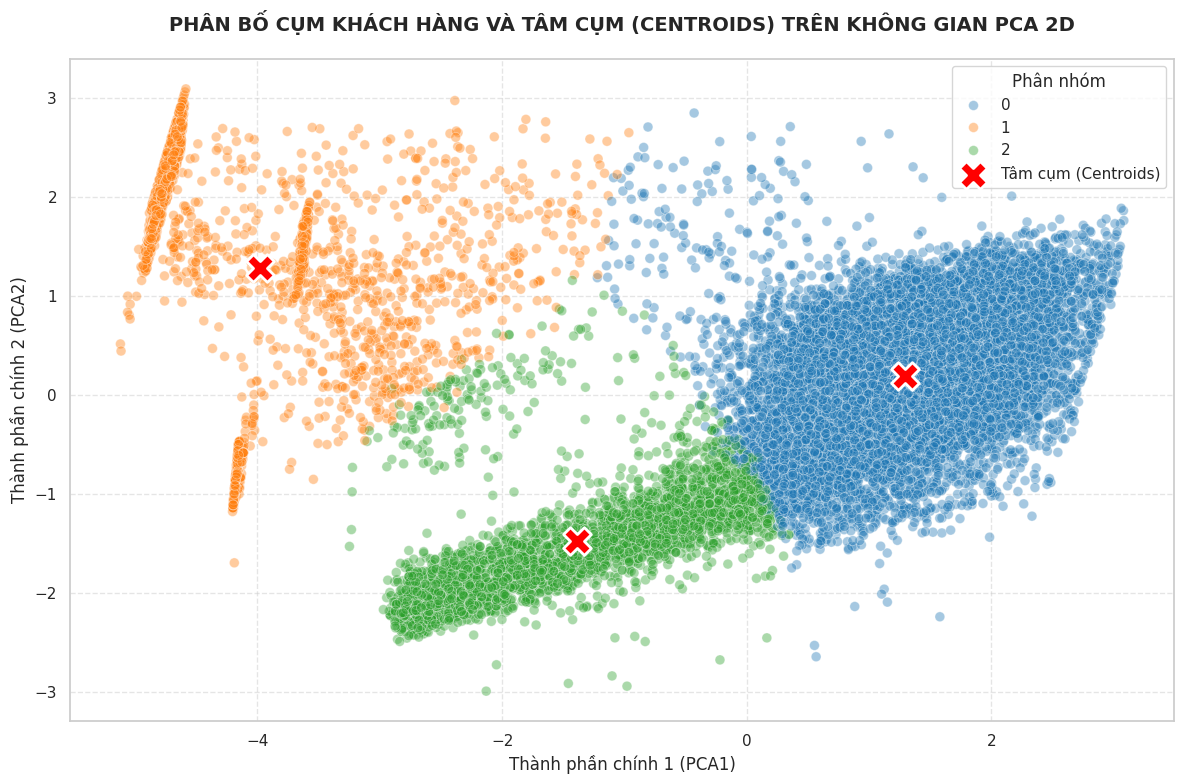

In [ ]:
# ==========================================
# 4.3.1 - SCATTER PLOT PCA 2D (VỚI TÂM CỤM - CENTROIDS)
# ==========================================

# Gán nhãn cụm vào df_pca
df_pca['Cluster'] = df_final['Cluster'].values

# Ép tọa độ tâm cụm qua PCA để vẽ lên biểu đồ 2D
tam_cum_2d = pca_2d.transform(kmeans_final.cluster_centers_)

print("TỌA ĐỘ TÂM CỤM SAU KHI NÉN XUỐNG 2 CHIỀU (PCA1, PCA2):")
tam_cum_2d_df = pd.DataFrame(
    tam_cum_2d,
    columns=['Tọa độ X (PCA1)', 'Tọa độ Y (PCA2)'],
    index=['Cụm 0', 'Cụm 1', 'Cụm 2']
)
display(tam_cum_2d_df.round(3))

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=['tab:blue', 'tab:orange', 'tab:green'],
    data=df_pca, alpha=0.4, s=50
)
# Vẽ tâm cụm (dấu X màu đỏ)
plt.scatter(
    tam_cum_2d[:, 0], tam_cum_2d[:, 1],
    c='red', marker='X', s=400, edgecolor='white', linewidth=2,
    label='Tâm cụm (Centroids)', zorder=10
)
plt.title('PHÂN BỐ CỤM KHÁCH HÀNG VÀ TÂM CỤM (CENTROIDS) TRÊN KHÔNG GIAN PCA 2D',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Thành phần chính 1 (PCA1)')
plt.ylabel('Thành phần chính 2 (PCA2)')
plt.legend(title='Phân nhóm', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

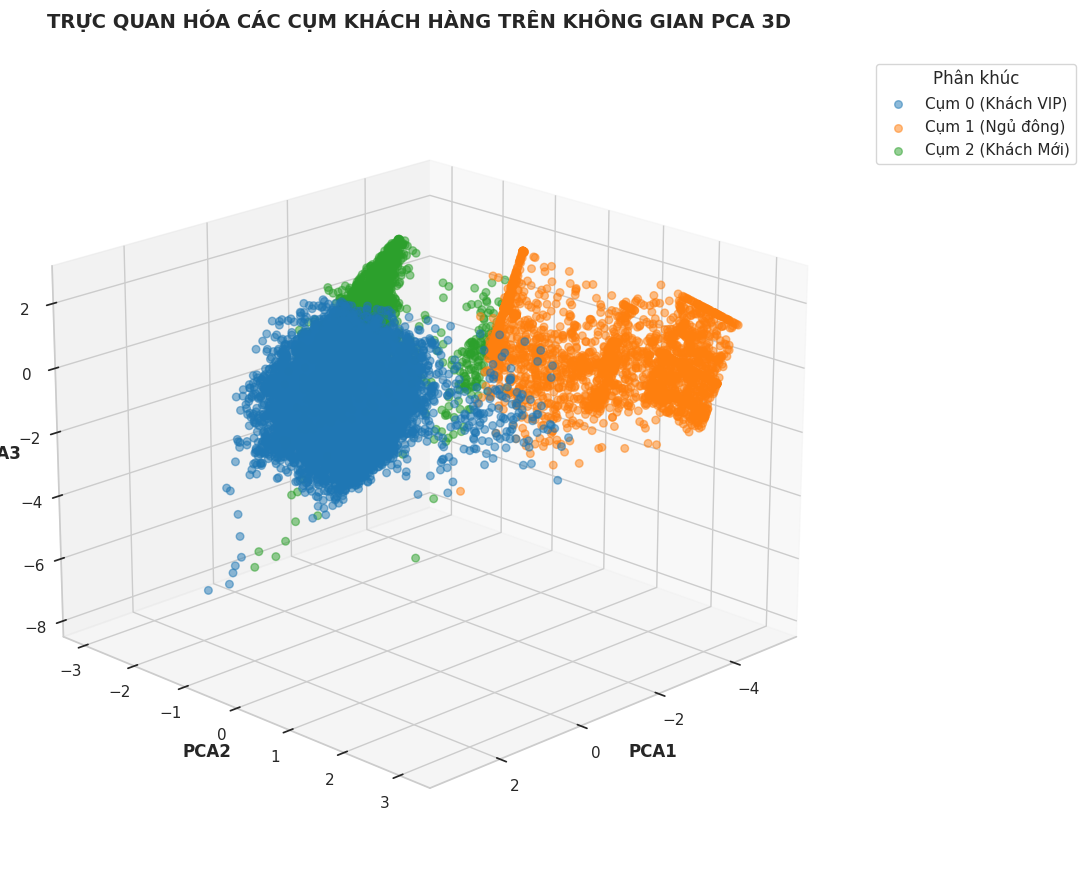

Tỷ lệ thông tin giữ lại qua 3 chiều PCA: 82.09%


In [ ]:
# ==========================================
# TRỰC QUAN HÓA KHÔNG GIAN 3 CHIỀU (PCA 3D)
# ==========================================
pca_3d = PCA(n_components=3, random_state=42)
components_3d = pca_3d.fit_transform(df_scaled)

df_3d = pd.DataFrame(data=components_3d, columns=['PCA1', 'PCA2', 'PCA3'])
df_3d['Cluster'] = df_final['Cluster'].values

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}
cluster_names = {0: 'Cụm 0 (Khách VIP)', 1: 'Cụm 1 (Ngủ đông)', 2: 'Cụm 2 (Khách Mới)'}

for cluster_num in [0, 1, 2]:
    subset = df_3d[df_3d['Cluster'] == cluster_num]
    ax.scatter(
        subset['PCA1'], subset['PCA2'], subset['PCA3'],
        c=colors[cluster_num], label=cluster_names[cluster_num],
        alpha=0.5, s=30
    )

ax.set_title('TRỰC QUAN HÓA CÁC CỤM KHÁCH HÀNG TRÊN KHÔNG GIAN PCA 3D',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('PCA1', fontweight='bold')
ax.set_ylabel('PCA2', fontweight='bold')
ax.set_zlabel('PCA3', fontweight='bold')
ax.view_init(elev=20, azim=45)
plt.legend(title='Phân khúc', loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

explained_variance_3d = sum(pca_3d.explained_variance_ratio_) * 100
print(f"Tỷ lệ thông tin giữ lại qua 3 chiều PCA: {explained_variance_3d:.2f}%")

In [ ]:
# ==========================================
# 4.3.2 - THỐNG KÊ MÔ TẢ VÀ ĐỊNH DANH CHÂN DUNG KHÁCH HÀNG
# ==========================================
analyze_cols = [
    'Enrollment_Duration_Months',   # L
    'Recency_Months',               # R
    'Total_Flights_Sum',            # F
    'Total_Distance_Sum',           # M (khoảng cách)
    'Total_Points_Accumulated',     # M (điểm)
    'Total_Points_Redeemed',        # C (chi phí)
    'Is_Cancelled',                 # C (hủy thẻ)
    'Salary'
]

cluster_summary = df_final.groupby('Cluster')[analyze_cols].mean().round(2)
print("BẢNG GIÁ TRỊ TRUNG BÌNH (MEAN) ĐẶC TRƯNG HÀNH VI LRFMC THEO CỤM:")
display(cluster_summary)

BẢNG GIÁ TRỊ TRUNG BÌNH (MEAN) ĐẶC TRƯNG HÀNH VI LRFMC THEO CỤM:


,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Distance_Sum,Total_Points_Accumulated,Total_Points_Redeemed,Is_Cancelled,Salary
Cluster,,,,,,,,
0,46.99,0.51,164.35,38658.93,3953.84,974.45,0.01,74556.54
1,38.71,20.28,18.51,4254.82,433.44,101.30,0.75,74359.92
2,10.49,0.59,66.02,15504.51,1590.51,338.17,0.04,72915.28


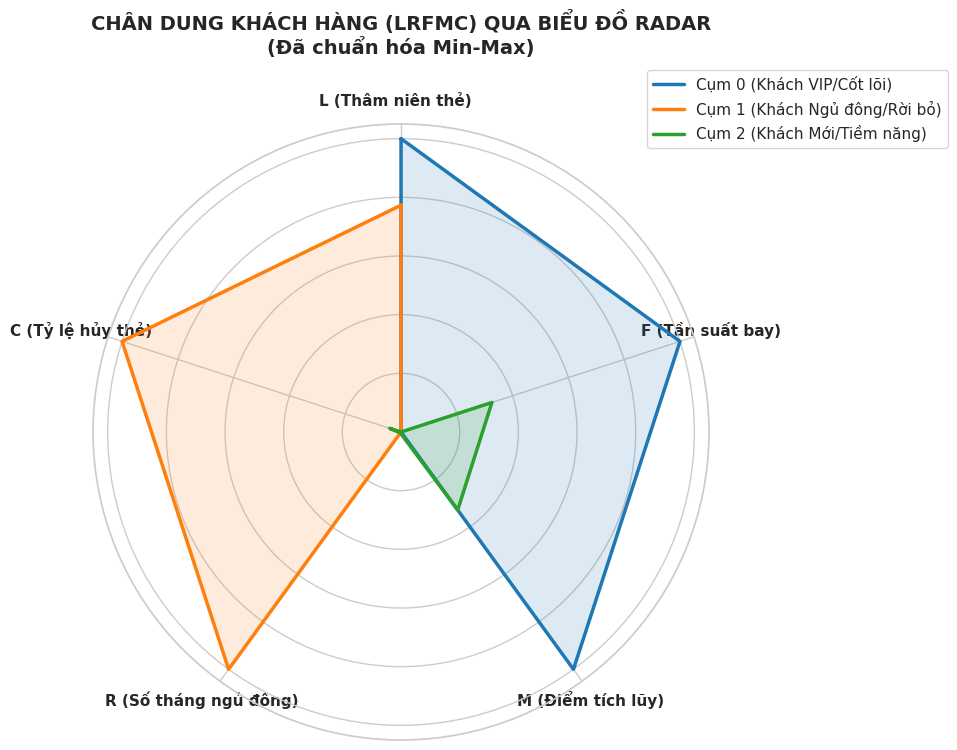

In [ ]:
# ==========================================
# BIỂU ĐỒ NHỆN (RADAR CHART) - CHÂN DUNG 3 CỤM KHÁCH HÀNG
# ==========================================
from sklearn.preprocessing import MinMaxScaler

# Sắp xếp trục: Tích cực (L, F, M) → Rủi ro (R, C)
radar_cols = [
    'Enrollment_Duration_Months',   # L (Tích cực)
    'Total_Flights_Sum',            # F (Tích cực)
    'Total_Points_Accumulated',     # M (Tích cực)
    'Recency_Months',               # R (Rủi ro)
    'Is_Cancelled'                  # C (Rủi ro)
]
radar_data = cluster_summary[radar_cols].copy()

# Chuẩn hóa Min-Max về thang đo [0, 1]
scaler_radar = MinMaxScaler()
radar_scaled = scaler_radar.fit_transform(radar_data)

labels_radar = np.array([
    'L (Thâm niên thẻ)  ',
    'F (Tần suất bay)  ',
    'M (Điểm tích lũy)  ',
    'R (Số tháng ngủ đông)  ',
    'C (Tỷ lệ hủy thẻ)  '
])
num_vars = len(labels_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

colors_radar = ['tab:blue', 'tab:orange', 'tab:green']
cluster_names_radar = ['Cụm 0 (Khách VIP/Cốt lõi)', 'Cụm 1 (Khách Ngủ đông/Rời bỏ)', 'Cụm 2 (Khách Mới/Tiềm năng)']

for i in range(3):
    values = radar_scaled[i].tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors_radar[i], linewidth=2.5, label=cluster_names_radar[i])
    ax.fill(angles, values, color=colors_radar[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11, fontweight='bold')
ax.set_yticklabels([])
plt.title('CHÂN DUNG KHÁCH HÀNG (LRFMC) QUA BIỂU ĐỒ RADAR\n(Đã chuẩn hóa Min-Max)',
          size=14, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.show()

/tmp/ipykernel_6663/1121216951.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df_final, ax=axes[i], palette=colors_box)
/tmp/ipykernel_6663/1121216951.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df_final, ax=axes[i], palette=colors_box)
/tmp/ipykernel_6663/1121216951.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y=feature, data=df_final, ax=axes[i], palette=colors_box)
/tmp/ipykernel_6663/1121216951.py:19: FutureWarning: 

Passing `palette` without a

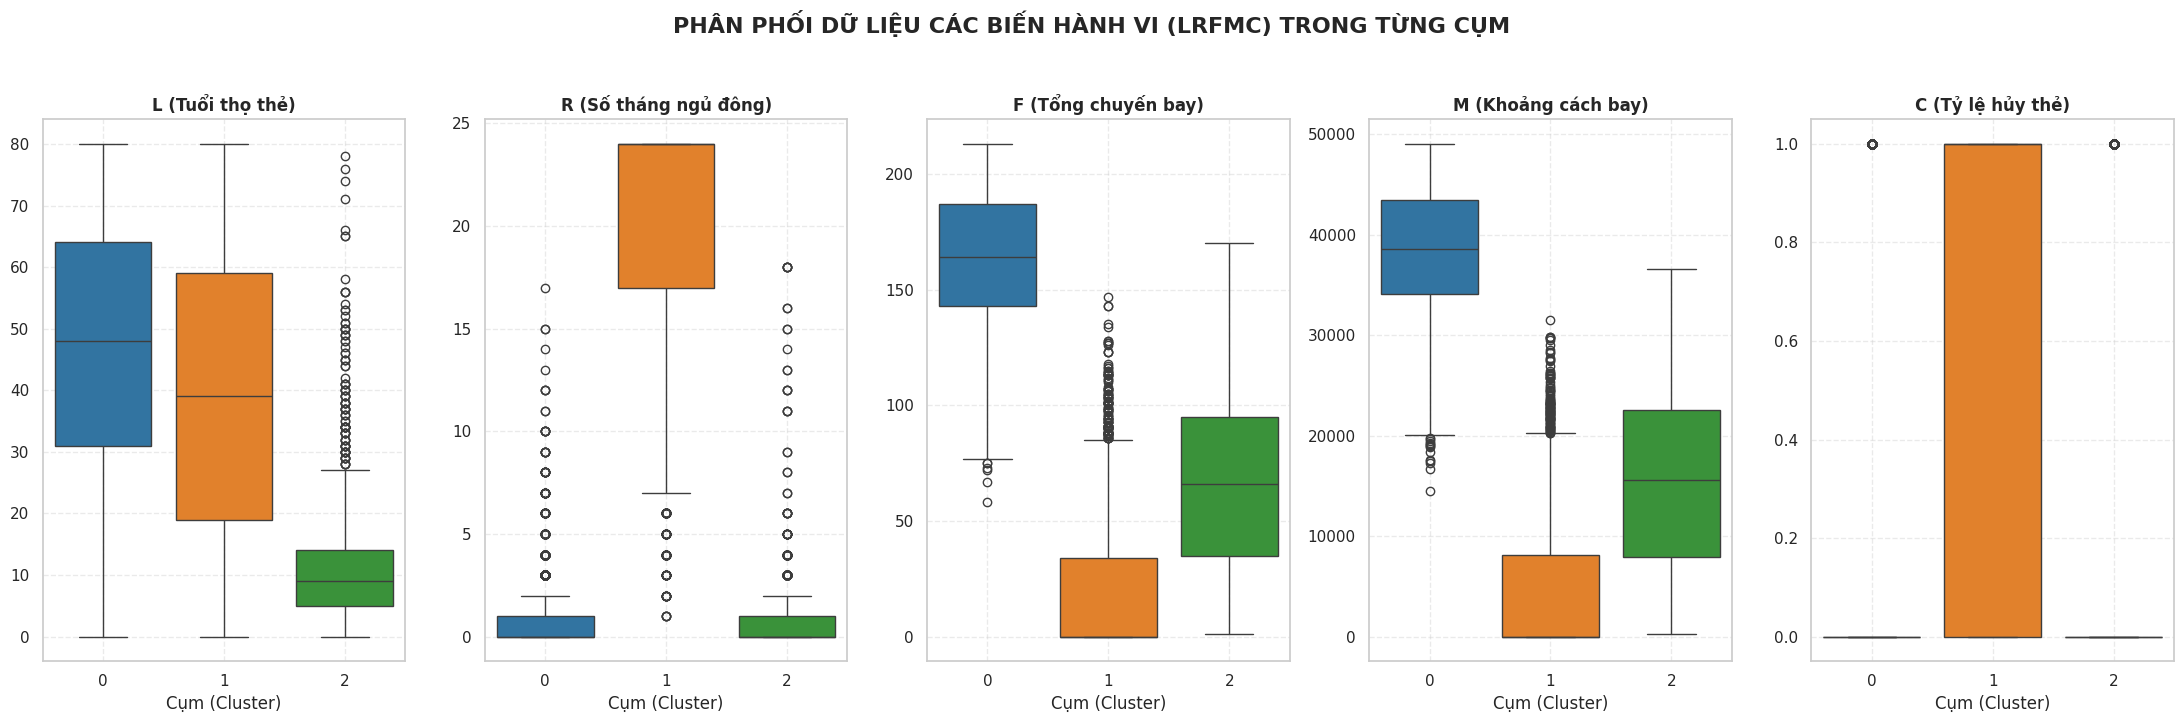

In [ ]:
# ==========================================
# 4.3.3 - KIỂM CHỨNG PHÂN PHỐI BẰNG BOXPLOT
# ==========================================
features_box = [
    'Enrollment_Duration_Months', 'Recency_Months',
    'Total_Flights_Sum', 'Total_Distance_Sum', 'Is_Cancelled'
]
titles_box = [
    'L (Tuổi thọ thẻ)', 'R (Số tháng ngủ đông)',
    'F (Tổng chuyến bay)', 'M (Khoảng cách bay)', 'C (Tỷ lệ hủy thẻ)'
]

fig, axes = plt.subplots(1, 5, figsize=(22, 7))
fig.suptitle('PHÂN PHỐI DỮ LIỆU CÁC BIẾN HÀNH VI (LRFMC) TRONG TỪNG CỤM',
             fontsize=16, fontweight='bold', y=1.03)

colors_box = ['tab:blue', 'tab:orange', 'tab:green']
for i, feature in enumerate(features_box):
    sns.boxplot(x='Cluster', y=feature, data=df_final, ax=axes[i], palette=colors_box)
    axes[i].set_title(titles_box[i], fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Cụm (Cluster)')
    axes[i].set_ylabel('')
    axes[i].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

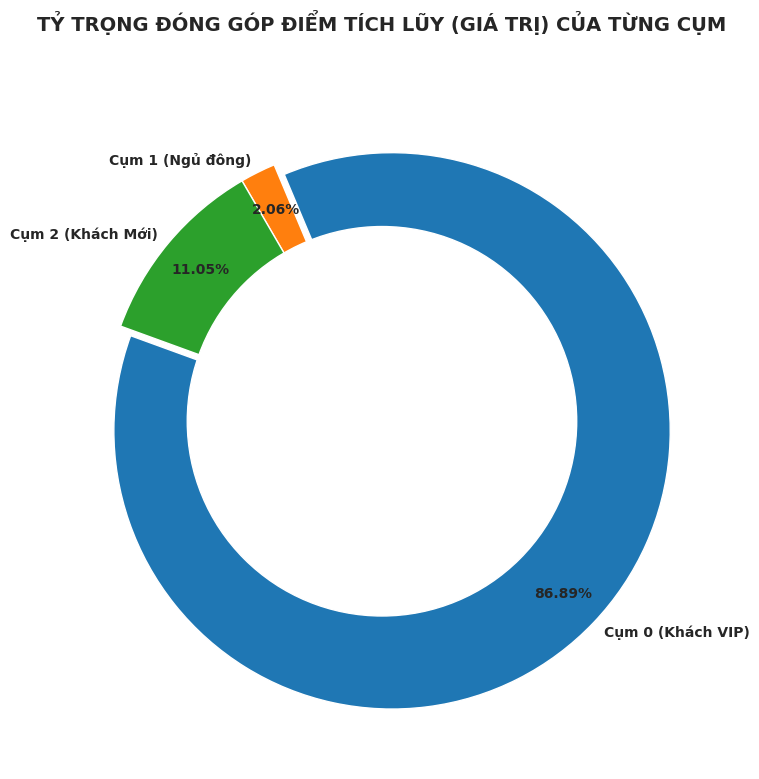


TỶ TRỌNG GIÁ TRỊ ĐÓNG GÓP TỪNG CỤM:
  Cụm 0: 43,187,784.44 điểm (86.89%)
  Cụm 1: 1,022,918.92 điểm (2.06%)
  Cụm 2: 5,493,621.91 điểm (11.05%)


In [ ]:
# ==========================================
# 4.3.4 - TỶ TRỌNG ĐÓNG GÓP GIÁ TRỊ (DONUT CHART)
# ==========================================
value_contribution = df_final.groupby('Cluster')['Total_Points_Accumulated'].sum()

plt.figure(figsize=(8, 8))
colors_donut = ['tab:blue', 'tab:orange', 'tab:green']
labels_donut = ['Cụm 0 (Khách VIP)', 'Cụm 1 (Ngủ đông)', 'Cụm 2 (Khách Mới)']
explode = (0.05, 0, 0)

plt.pie(
    value_contribution,
    labels=labels_donut,
    colors=colors_donut,
    autopct='%1.2f%%',
    startangle=160,
    pctdistance=0.85,
    explode=explode,
    textprops={'fontsize': 10, 'fontweight': 'bold'},
    labeldistance=1.05,
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('TỶ TRỌNG ĐÓNG GÓP ĐIỂM TÍCH LŨY (GIÁ TRỊ) CỦA TỪNG CỤM',
          fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\nTỶ TRỌNG GIÁ TRỊ ĐÓNG GÓP TỪNG CỤM:")
total = value_contribution.sum()
for cluster_num, val in value_contribution.items():
    print(f"  Cụm {cluster_num}: {val:,.2f} điểm ({val/total*100:.2f}%)")

In [ ]:
# ==========================================
# XUẤT KẾT QUẢ PHÂN CỤM RA EXCEL
# ==========================================
df_final.to_excel('Ketqua_phancum.xlsx', index=False)
print("Đã xuất file 'Ketqua_phancum.xlsx' thành công!")

Đã xuất file 'Ketqua_phancum.xlsx' thành công!


## 4.3.5. Kiểm chứng độ tin cậy phân cụm bằng Fuzzy C-Means (FCM)
*FCM là thuật toán phân cụm mềm (Soft Clustering): mỗi khách hàng được gán mức độ thuộc về (membership) cho từng cụm thay vì bị gán cứng vào 1 nhóm duy nhất như K-Means. Phần này dùng FCM như một công cụ kiểm chứng độc lập để xác nhận tính ổn định của kết quả phân cụm K-Means.*

In [ ]:
# ==========================================
# IMPLEMENT FCM (FUZZY C-MEANS) BẰNG NUMPY
# ==========================================
import numpy as np
import pandas as pd

class FuzzyCMeans:
    """
    Fuzzy C-Means Clustering (FCM)
    Tham số:
        n_clusters (C) : Số cụm
        m              : Hệ số mờ (fuzziness), thường = 2
        max_iter       : Số vòng lặp tối đa
        tol            : Ngưỡng hội tụ (thay đổi tâm cụm nhỏ hơn tol thì dừng)
        random_state   : Seed để tái tạo kết quả
    """
    def __init__(self, n_clusters=3, m=2, max_iter=150, tol=1e-4, random_state=42):
        self.n_clusters  = n_clusters
        self.m           = m
        self.max_iter    = max_iter
        self.tol         = tol
        self.random_state = random_state

    def fit(self, X):
        np.random.seed(self.random_state)
        N, D = X.shape
        C = self.n_clusters

        # --- BƯỚC 1: Khởi tạo ma trận membership ngẫu nhiên ---
        # U[i, j] = mức độ thành viên của điểm i vào cụm j
        U = np.random.dirichlet(np.ones(C), size=N)  # Đảm bảo sum mỗi hàng = 1

        self.n_iter_ = 0
        for iteration in range(self.max_iter):
            U_old = U.copy()

            # --- BƯỚC 2: Cập nhật tâm cụm (Weighted Mean) ---
            # v_j = sum(u_ij^m * x_i) / sum(u_ij^m)
            Um = U ** self.m                        # (N, C)
            centers = (Um.T @ X) / Um.sum(axis=0)[:, None]  # (C, D)

            # --- BƯỚC 3: Cập nhật ma trận membership ---
            # Tính khoảng cách bình phương từ mỗi điểm đến từng tâm cụm
            dist_sq = np.zeros((N, C))
            for j in range(C):
                diff = X - centers[j]               # (N, D)
                dist_sq[:, j] = np.sum(diff ** 2, axis=1)  # (N,)

            # Tránh chia cho 0 khi điểm trùng với tâm cụm
            dist_sq = np.fmax(dist_sq, np.finfo(float).eps)

            # Cập nhật U theo công thức FCM
            exp = 2.0 / (self.m - 1)    # = 2 khi m=2
            U_new = np.zeros((N, C))
            for j in range(C):
                ratio = dist_sq[:, j:j+1] / dist_sq  # (N, C)
                U_new[:, j] = 1.0 / np.sum(ratio ** exp, axis=1)

            U = U_new
            self.n_iter_ += 1

            # --- BƯỚC 4: Kiểm tra hội tụ ---
            if np.max(np.abs(U - U_old)) < self.tol:
                break

        self.centers_     = centers   # Tâm cụm cuối cùng (C, D)
        self.u_matrix_    = U          # Ma trận membership (N, C)
        # Hard label: gán cụm có membership cao nhất
        self.labels_      = np.argmax(U, axis=1)
        # Tính WCSS (để so sánh với K-Means)
        self.inertia_     = self._compute_wcss(X)
        return self

    def _compute_wcss(self, X):
        wcss = 0.0
        for j in range(self.n_clusters):
            mask = self.labels_ == j
            if mask.sum() > 0:
                diff = X[mask] - self.centers_[j]
                wcss += np.sum(diff ** 2)
        return wcss

    def predict(self, X):
        """Gán nhãn cứng cho dữ liệu mới dựa trên khoảng cách đến tâm cụm."""
        dist_sq = np.array([
            np.sum((X - self.centers_[j]) ** 2, axis=1)
            for j in range(self.n_clusters)
        ]).T
        return np.argmin(dist_sq, axis=1)

print("Class FuzzyCMeans đã được định nghĩa thành công!")

Class FuzzyCMeans đã được định nghĩa thành công!


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mode
from sklearn.metrics import adjusted_rand_score

X_arr = df_scaled.values

print("Đang chạy Fuzzy C-Means (C=3, m=2)... Vui lòng đợi...")
fcm = FuzzyCMeans(n_clusters=3, m=2, max_iter=150, tol=1e-4, random_state=42)
fcm.fit(X_arr)

# --- ĐỒNG NHẤT NHÃN VÀ CỘT MEMBERSHIP ---
km_labels = df_final['Cluster'].values
raw_fcm_labels = np.argmax(fcm.u_matrix_, axis=1)

# Tìm ánh xạ từ cột FCM (0,1,2) sang nhãn K-Means (0,1,2)
mapping = {}
for i in range(3):
    # Với mỗi cột i của FCM, xem nhãn K-Means nào xuất hiện nhiều nhất
    mask = (raw_fcm_labels == i)
    if np.any(mask):
        matched_label = mode(km_labels[mask], keepdims=True)[0][0]
        mapping[i] = matched_label

# Tạo ma trận membership đã sắp xếp lại cột để khớp với nhãn 0, 1, 2
# Nếu mapping là {0:2, 1:1, 2:0}, ta sẽ đổi chỗ các cột
new_u_matrix = np.zeros_like(fcm.u_matrix_)
for old_idx, new_idx in mapping.items():
    new_u_matrix[:, new_idx] = fcm.u_matrix_[:, old_idx]

# Cập nhật lại model FCM với dữ liệu đã đồng bộ
fcm.u_matrix_ = new_u_matrix
fcm.labels_ = np.argmax(new_u_matrix, axis=1)
df_final['Cluster_FCM'] = fcm.labels_

print(f" FCM hội tụ sau {fcm.n_iter_} vòng lặp.")
print(f" Đã đồng bộ cột Membership và Nhãn FCM khớp với K-Means (ARI = {adjusted_rand_score(km_labels, fcm.labels_):.4f})")

print("\nSỐ LƯỢNG KHÁCH HÀNG SAU KHI ĐỒNG NHẤT:")
print("-" * 45)
fcm_counts = pd.Series(fcm.labels_).value_counts().sort_index()
for cluster_num, count in fcm_counts.items():
    pct = count / len(df_final) * 100
    print(f"  Cụm FCM {cluster_num}: {count:,} khách hàng ({pct:.2f}%)")
print("-" * 45)

Đang chạy Fuzzy C-Means (C=3, m=2)... Vui lòng đợi...
 FCM hội tụ sau 26 vòng lặp.
 Đã đồng bộ cột Membership và Nhãn FCM khớp với K-Means (ARI = 0.9913)

SỐ LƯỢNG KHÁCH HÀNG SAU KHI ĐỒNG NHẤT:
---------------------------------------------
  Cụm FCM 0: 10,891 khách hàng (65.07%)
  Cụm FCM 1: 2,335 khách hàng (13.95%)
  Cụm FCM 2: 3,511 khách hàng (20.98%)
---------------------------------------------


MA TRẬN MEMBERSHIP — 10 KHÁCH HÀNG ĐẦU TIÊN:
---------------------------------------------------------------------------


,Membership_Cụm0 (VIP),Membership_Cụm1 (Ngủ đông),Membership_Cụm2 (Mới),Hard_Label_FCM,Hard_Label_KMeans
0,0.9856,0.0019,0.0125,0,0
1,0.9671,0.0047,0.0281,0,0
2,0.0917,0.7751,0.1333,1,1
3,0.9922,0.0012,0.0066,0,0
4,0.8283,0.0234,0.1483,0,0
5,0.9547,0.0106,0.0347,0,0
6,0.9926,0.0012,0.0062,0,0
7,0.9050,0.0104,0.0846,0,0
8,0.9001,0.0121,0.0877,0,0
9,0.8816,0.0146,0.1038,0,0



KHÁCH HÀNG 'LƯỠNG LỰ' (membership cao nhất < 0.6):
  → Có 1,201 khách hàng (7.18%) nằm ở ranh giới.


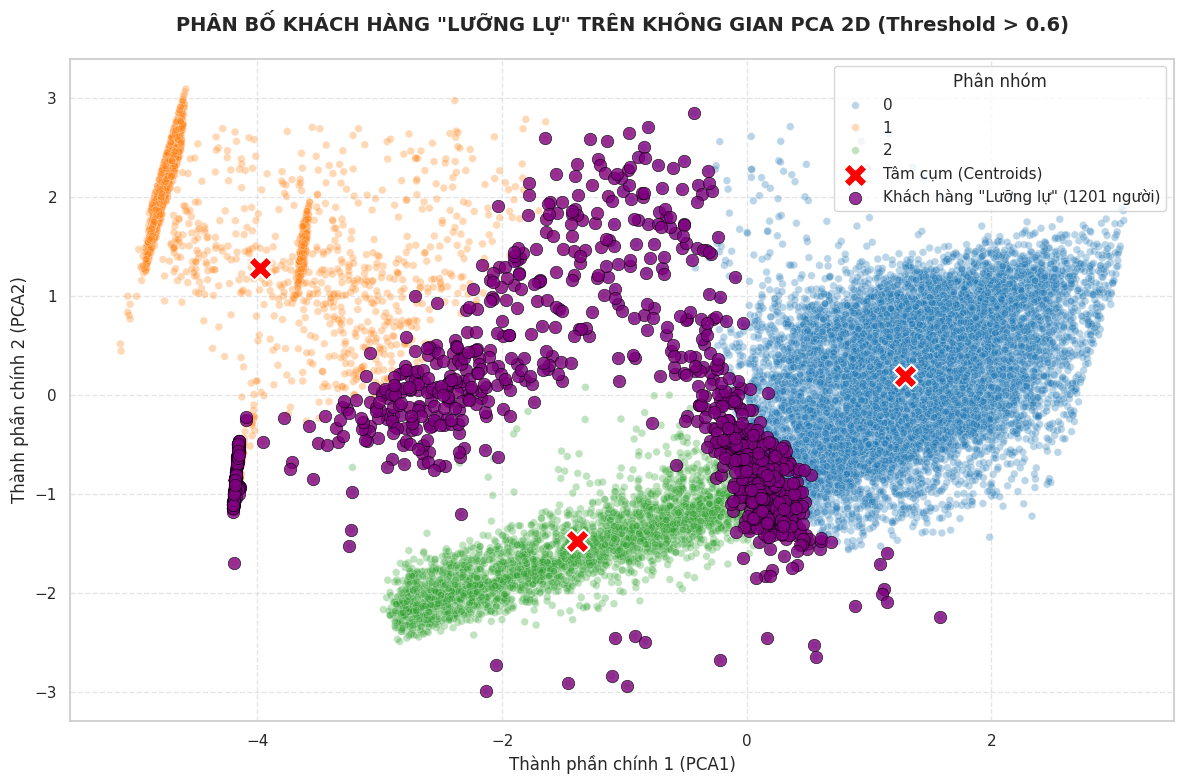

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo DataFrame membership từ ma trận đã được sắp xếp lại cột
df_membership = pd.DataFrame(
    fcm.u_matrix_,
    columns=['Membership_Cụm0 (VIP)', 'Membership_Cụm1 (Ngủ đông)', 'Membership_Cụm2 (Mới)']
).round(4)

df_membership['Hard_Label_FCM'] = fcm.labels_
df_membership['Hard_Label_KMeans'] = df_final['Cluster'].values

print("MA TRẬN MEMBERSHIP — 10 KHÁCH HÀNG ĐẦU TIÊN:")
print("-" * 75)
display(df_membership.head(10))

# --- Phát hiện khách hàng 'lưỡng lự' ---
threshold = 0.6
max_membership = fcm.u_matrix_.max(axis=1)
ambiguous_mask = max_membership < threshold
n_ambiguous = ambiguous_mask.sum()

print(f"\nKHÁCH HÀNG 'LƯỠNG LỰ' (membership cao nhất < {threshold}):")
print(f"  → Có {n_ambiguous:,} khách hàng ({n_ambiguous/len(df_final)*100:.2f}%) nằm ở ranh giới.")

# ==========================================
# TRỰC QUAN HÓA KHÁCH HÀNG LƯỠNG LỰ TRÊN PCA 2D
# ==========================================
# Lấy dữ liệu PCA và K-Means clusters
df_pca['Cluster'] = df_final['Cluster'].values

# Lọc ra khách hàng lưỡng lự
df_ambiguous = df_pca[ambiguous_mask].copy()

plt.figure(figsize=(12, 8))

# Vẽ tất cả khách hàng (background)
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=['tab:blue', 'tab:orange', 'tab:green'],
    data=df_pca, alpha=0.3, s=30,  # Giảm alpha và kích thước để dễ nhìn khách hàng lưỡng lự
    legend='full'
)

# Vẽ tâm cụm (để định vị)
# Lấy tâm cụm 2D từ cell FghzPgYP-yV3 nếu đã chạy
# Hoặc tính toán lại nếu cần thiết (ví dụ: pca_2d.transform(kmeans_final.cluster_centers_))
if 'tam_cum_2d' in globals():
    plt.scatter(
        tam_cum_2d[:, 0], tam_cum_2d[:, 1],
        c='red', marker='X', s=300, edgecolor='white', linewidth=1.5,
        label='Tâm cụm (Centroids)', zorder=10
    )

# Tô đậm khách hàng lưỡng lự
sns.scatterplot(
    x='PCA1', y='PCA2',
    data=df_ambiguous,
    color='purple',  # Màu đặc biệt cho khách hàng lưỡng lự
    marker='o', s=80, alpha=0.8, edgecolor='black', linewidth=0.5,
    label=f'Khách hàng "Lưỡng lự" ({n_ambiguous} người)',
    zorder=5
)

plt.title(f'PHÂN BỐ KHÁCH HÀNG "LƯỠNG LỰ" TRÊN KHÔNG GIAN PCA 2D (Threshold > {threshold})',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Thành phần chính 1 (PCA1)')
plt.ylabel('Thành phần chính 2 (PCA2)')
plt.legend(title='Phân nhóm', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# SO SÁNH CHỈ SỐ ĐÁNH GIÁ: FCM vs K-MEANS
# Dùng hard labels của FCM để tính các chỉ số nội bộ
# ==========================================
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import KMeans

# Lấy lại kết quả K-Means K=3 đã chạy ở Chương 4
km_labels  = df_final['Cluster'].values
fcm_labels = fcm.labels_

# Tính chỉ số cho K-Means
km_sil  = silhouette_score(X_arr, km_labels)
km_dbi  = davies_bouldin_score(X_arr, km_labels)
km_chi  = calinski_harabasz_score(X_arr, km_labels)
km_wcss = kmeans_final.inertia_

# Tính chỉ số cho FCM (dùng hard labels)
fcm_sil  = silhouette_score(X_arr, fcm_labels)
fcm_dbi  = davies_bouldin_score(X_arr, fcm_labels)
fcm_chi  = calinski_harabasz_score(X_arr, fcm_labels)
fcm_wcss = fcm.inertia_

# Tạo bảng so sánh
df_compare = pd.DataFrame({
    'Chỉ số': [
        'WCSS (Inertia) ↓ thấp hơn tốt hơn',
        'Silhouette Score ↑ cao hơn tốt hơn',
        'Davies-Bouldin ↓ thấp hơn tốt hơn',
        'Calinski-Harabasz ↑ cao hơn tốt hơn'
    ],
    'K-Means (K=3)': [
        round(km_wcss, 4), round(km_sil, 4),
        round(km_dbi, 4),  round(km_chi, 4)
    ],
    'FCM (C=3, m=2)': [
        round(fcm_wcss, 4), round(fcm_sil, 4),
        round(fcm_dbi, 4),  round(fcm_chi, 4)
    ]
})

# Thêm cột đánh giá thắng/thua
winners = []
for _, row in df_compare.iterrows():
    chi_so = row['Chỉ số']
    km_val  = row['K-Means (K=3)']
    fcm_val = row['FCM (C=3, m=2)']
    if '↓' in chi_so:  # Thấp hơn tốt hơn
        winners.append('K-Means ' if km_val < fcm_val else 'FCM ' if fcm_val < km_val else 'Ngang bằng')
    else:               # Cao hơn tốt hơn
        winners.append('K-Means ' if km_val > fcm_val else 'FCM ' if fcm_val > km_val else 'Ngang bằng')
df_compare['Mô hình tốt hơn'] = winners

print("BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ CHẤT LƯỢNG CỤM: K-MEANS vs FCM")
print("=" * 75)
display(df_compare)
print("=" * 75)

BẢNG SO SÁNH CHỈ SỐ ĐÁNH GIÁ CHẤT LƯỢNG CỤM: K-MEANS vs FCM


,Chỉ số,K-Means (K=3),"FCM (C=3, m=2)",Mô hình tốt hơn
0,WCSS (Inertia) ↓ thấp hơn tốt hơn,58551.9628,59009.8111,K-Means
1,Silhouette Score ↑ cao hơn tốt hơn,0.3693,0.3689,K-Means
2,Davies-Bouldin ↓ thấp hơn tốt hơn,1.0113,1.0172,K-Means
3,Calinski-Harabasz ↑ cao hơn tốt hơn,10766.5690,10762.7241,K-Means


In [ ]:
# ==========================================
# ĐO MỨC ĐỘ ĐỒNG THUẬN GIỮA K-MEANS VÀ FCM
# Dùng Adjusted Rand Index (ARI) và so sánh phân bổ cụm
# ==========================================
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(km_labels, fcm_labels)
print("MỨC ĐỘ ĐỒNG THUẬN GIỮA K-MEANS VÀ FCM:")
print("-" * 50)
print(f"  Adjusted Rand Index (ARI) = {ari:.4f}")
if ari > 0.9:
    print("  → ARI rất cao: 2 thuật toán cho kết quả phân cụm RẤT TƯƠNG ĐỒNG nhau.")
elif ari > 0.7:
    print("  → ARI khá cao: 2 thuật toán cho kết quả TƯƠNG ĐỐI NHẤT QUÁN.")
else:
    print("  → ARI thấp: 2 thuật toán cho kết quả KHÁC BIỆT đáng kể.")
print()

# Bảng cross-tab so sánh nhãn K-Means vs FCM
print("BẢNG CHÉO NHÃN CỤM (CONFUSION-LIKE MATRIX): K-MEANS vs FCM")
print("(Số lượng khách hàng khớp nhau và lệch nhau giữa 2 thuật toán)")
crosstab = pd.crosstab(
    pd.Series(km_labels,  name='Nhãn K-Means'),
    pd.Series(fcm_labels, name='Nhãn FCM'),
    margins=True
)
display(crosstab)

# Tính % đồng thuận
total_matches = np.sum(km_labels == fcm_labels)
match_pct = (total_matches / len(km_labels)) * 100
print(f"\n=> Tổng mức độ khớp nhãn tuyệt đối: {match_pct:.2f}%")
print("Lưu ý: Sự lệch nhau nhỏ (<1%) là do cách tiếp cận 'mờ' của FCM đối với các khách hàng ranh giới.")

MỨC ĐỘ ĐỒNG THUẬN GIỮA K-MEANS VÀ FCM:
--------------------------------------------------
  Adjusted Rand Index (ARI) = 0.9913
  → ARI rất cao: 2 thuật toán cho kết quả phân cụm RẤT TƯƠNG ĐỒNG nhau.

BẢNG CHÉO NHÃN CỤM (CONFUSION-LIKE MATRIX): K-MEANS vs FCM
(Số lượng khách hàng khớp nhau và lệch nhau giữa 2 thuật toán)


Nhãn FCM,0,1,2,All
Nhãn K-Means,,,,
0,10891,1,31,10923
1,0,2334,26,2360
2,0,0,3454,3454
All,10891,2335,3511,16737



=> Tổng mức độ khớp nhãn tuyệt đối: 99.65%
Lưu ý: Sự lệch nhau nhỏ (<1%) là do cách tiếp cận 'mờ' của FCM đối với các khách hàng ranh giới.


In [ ]:
# ==========================================
# 4.3.5 - KẾT LUẬN SO SÁNH FCM vs K-MEANS
# ==========================================
import pandas as pd

print("KẾT LUẬN KIỂM CHỨNG BẰNG FUZZY C-MEANS:")
print("=" * 60)
print(f"1. ARI = {adjusted_rand_score(km_labels, fcm_labels):.4f}")
print("   → Hai thuật toán đồng thuận cao, cấu trúc 3 cụm là ổn định.")
print()
print(f"2. Khách hàng 'lưỡng lự' (membership < 0.6): {n_ambiguous:,} người "
      f"({n_ambiguous/len(df_final)*100:.2f}%)")
print("   → Nhóm này K-Means gán cứng vào 1 cụm nhưng thực tế nằm ở ranh giới.")
print("   → Đây là nhóm CRM cần theo dõi đặc biệt vì hành vi dễ dịch chuyển.")
print()

# Bảng tóm tắt so sánh 2 mô hình
df_summary = pd.DataFrame({
    'Tiêu chí': [
        'Loại phân cụm',
        'Số cụm',
        'Chỉ số Silhouette',
        'Davies-Bouldin',
        'Calinski-Harabasz',
        'Khách hàng lưỡng lự',
        'Vai trò trong dự án'
    ],
    'K-Means (Thuật toán chính)': [
        'Hard Clustering (Phân cụm cứng)',
        '3',
        f'{km_sil:.4f}',
        f'{km_dbi:.4f}',
        f'{km_chi:.2f}',
        'Không đo được',
        'Phân khúc + gán nhãn cho Decision Tree'
    ],
    'FCM (Kiểm chứng bổ sung)': [
        'Soft Clustering (Phân cụm mờ)',
        '3',
        f'{fcm_sil:.4f}',
        f'{fcm_dbi:.4f}',
        f'{fcm_chi:.2f}',
        f'{n_ambiguous:,} KH ({n_ambiguous/len(df_final)*100:.2f}%)',
        'Kiểm chứng tính ổn định của K-Means'
    ]
})

print("BẢNG TÓM TẮT SO SÁNH K-MEANS vs FCM:")
display(df_summary)
print("=" * 60)
print("=> K-Means được xác nhận là lựa chọn phù hợp: chỉ số tương đương FCM,")
print("   dễ triển khai CRM hơn và có thể kết hợp trực tiếp với Decision Tree.")


KẾT LUẬN KIỂM CHỨNG BẰNG FUZZY C-MEANS:
1. ARI = 0.9913
   → Hai thuật toán đồng thuận cao, cấu trúc 3 cụm là ổn định.

2. Khách hàng 'lưỡng lự' (membership < 0.6): 1,201 người (7.18%)
   → Nhóm này K-Means gán cứng vào 1 cụm nhưng thực tế nằm ở ranh giới.
   → Đây là nhóm CRM cần theo dõi đặc biệt vì hành vi dễ dịch chuyển.

BẢNG TÓM TẮT SO SÁNH K-MEANS vs FCM:


,Tiêu chí,K-Means (Thuật toán chính),FCM (Kiểm chứng bổ sung)
0,Loại phân cụm,Hard Clustering (Phân cụm cứng),Soft Clustering (Phân cụm mờ)
1,Số cụm,3,3
2,Chỉ số Silhouette,0.3693,0.3689
3,Davies-Bouldin,1.0113,1.0172
4,Calinski-Harabasz,10766.57,10762.72
5,Khách hàng lưỡng lự,Không đo được,"1,201 KH (7.18%)"
6,Vai trò trong dự án,Phân khúc + gán nhãn cho Decision Tree,Kiểm chứng tính ổn định của K-Means


=> K-Means được xác nhận là lựa chọn phù hợp: chỉ số tương đương FCM,
   dễ triển khai CRM hơn và có thể kết hợp trực tiếp với Decision Tree.


---
# CHƯƠNG 5: PHÂN LỚP KHÁCH HÀNG BẰNG THUẬT TOÁN DECISION TREE

In [ ]:
# ==========================================
# 5.1. XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH DECISION TREE
# 5.1.1 + 5.1.2 + 5.1.3: Tiêu chí phân nhánh + Tuning + Pruning (GridSearchCV)
# ==========================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# 1. CHUẨN BỊ DỮ LIỆU (dùng dữ liệu gốc chưa chuẩn hóa để luật dễ diễn giải)
X = df_final[[
    'Enrollment_Duration_Months', 'Recency_Months',
    'Total_Flights_Sum', 'Total_Distance_Sum',
    'Total_Points_Accumulated', 'Total_Points_Redeemed',
    'Is_Cancelled', 'Salary'
]]
y = df_final['Cluster']  # Nhãn từ K-Means

# Chia Train (80%) / Test (20%), stratify để giữ tỷ lệ cụm đồng đều
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. TINH CHỈNH SIÊU THAM SỐ VÀ CẮT TỈA CÂY (GridSearchCV, CV=5)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [10, 30, 50],
    'ccp_alpha': [0.0, 0.001, 0.005]
}

dt_base = DecisionTreeClassifier(random_state=42)
print("Đang tìm kiếm bộ siêu tham số tối ưu (GridSearchCV)... Vui lòng đợi...")
grid_search = GridSearchCV(estimator=dt_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

print("-" * 55)
print("HUẤN LUYỆN THÀNH CÔNG! BỘ THAM SỐ TỐI ƯU NHẤT LÀ:")
print(f"  - Tiêu chí phân nhánh (criterion)  : {best_dt.criterion}")
print(f"  - Độ sâu tối đa (max_depth)         : {best_dt.max_depth}")
print(f"  - Số mẫu tối thiểu ở nút lá         : {best_dt.min_samples_leaf}")
print(f"  - Hệ số cắt tỉa (ccp_alpha)         : {best_dt.ccp_alpha}")
print("-" * 55)

Đang tìm kiếm bộ siêu tham số tối ưu (GridSearchCV)... Vui lòng đợi...
-------------------------------------------------------
HUẤN LUYỆN THÀNH CÔNG! BỘ THAM SỐ TỐI ƯU NHẤT LÀ:
  - Tiêu chí phân nhánh (criterion)  : gini
  - Độ sâu tối đa (max_depth)         : 6
  - Số mẫu tối thiểu ở nút lá         : 10
  - Hệ số cắt tỉa (ccp_alpha)         : 0.0
-------------------------------------------------------


In [ ]:
# ==========================================
# 5.1.1 - SO SÁNH TIÊU CHÍ PHÂN NHÁNH: GINI vs ENTROPY
# ==========================================
cv_results_df = pd.DataFrame(grid_search.cv_results_)
best_score_gini    = cv_results_df[cv_results_df['param_criterion'] == 'gini']['mean_test_score'].max()
best_score_entropy = cv_results_df[cv_results_df['param_criterion'] == 'entropy']['mean_test_score'].max()

print("SO SÁNH TIÊU CHÍ PHÂN NHÁNH (TRÊN TẬP CROSS-VALIDATION):")
print(f"  - Độ chính xác cao nhất khi dùng 'gini'   : {best_score_gini * 100:.2f}%")
print(f"  - Độ chính xác cao nhất khi dùng 'entropy': {best_score_entropy * 100:.2f}%")
print(f"=> Mô hình chọn: '{best_dt.criterion}' là tiêu chí tối ưu.")

SO SÁNH TIÊU CHÍ PHÂN NHÁNH (TRÊN TẬP CROSS-VALIDATION):
  - Độ chính xác cao nhất khi dùng 'gini'   : 98.05%
  - Độ chính xác cao nhất khi dùng 'entropy': 97.98%
=> Mô hình chọn: 'gini' là tiêu chí tối ưu.


In [ ]:
# ==========================================
# 5.1.4 - KẾT QUẢ HUẤN LUYỆN (TRAIN vs TEST ACCURACY)
# ==========================================
train_acc = best_dt.score(X_train, y_train)
test_acc  = best_dt.score(X_test, y_test)

print(f"Độ chính xác (Accuracy) trên tập Train : {train_acc * 100:.2f}%")
print(f"Độ chính xác (Accuracy) trên tập Test  : {test_acc * 100:.2f}%")
print(f"Biên độ chênh lệch                      : {abs(train_acc - test_acc) * 100:.2f}% → Không bị Overfitting")

Độ chính xác (Accuracy) trên tập Train : 98.60%
Độ chính xác (Accuracy) trên tập Test  : 97.85%
Biên độ chênh lệch                      : 0.75% → Không bị Overfitting


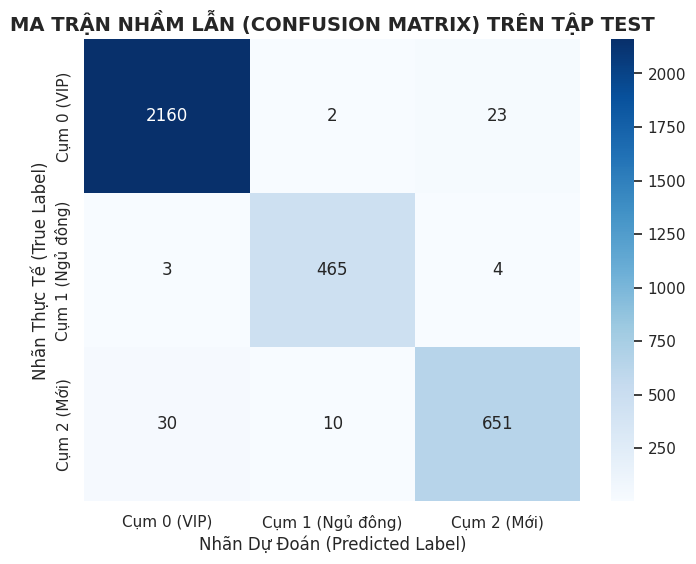

In [ ]:
# ==========================================
# 5.2 - ĐÁNH GIÁ MÔ HÌNH PHÂN LỚP
# 5.2.1 - CONFUSION MATRIX (MA TRẬN NHẦM LẪN)
# ==========================================
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

y_pred = best_dt.predict(X_test)

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Cụm 0 (VIP)', 'Cụm 1 (Ngủ đông)', 'Cụm 2 (Mới)'],
    yticklabels=['Cụm 0 (VIP)', 'Cụm 1 (Ngủ đông)', 'Cụm 2 (Mới)']
)
plt.title('MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST', fontsize=14, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted Label)')
plt.ylabel('Nhãn Thực Tế (True Label)')
plt.show()

In [ ]:
# ==========================================
# 5.2.2 - ACCURACY, PRECISION, RECALL, F1-SCORE
# ==========================================
print("BÁO CÁO ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH (CLASSIFICATION REPORT):")
print("-" * 65)
print(classification_report(
    y_test, y_pred,
    target_names=['Cụm 0 (VIP)', 'Cụm 1 (Ngủ đông)', 'Cụm 2 (Mới)']
))
print("-" * 65)

BÁO CÁO ĐÁNH GIÁ CHẤT LƯỢNG MÔ HÌNH (CLASSIFICATION REPORT):
-----------------------------------------------------------------
                  precision    recall  f1-score   support

     Cụm 0 (VIP)       0.98      0.99      0.99      2185
Cụm 1 (Ngủ đông)       0.97      0.99      0.98       472
     Cụm 2 (Mới)       0.96      0.94      0.95       691

        accuracy                           0.98      3348
       macro avg       0.97      0.97      0.97      3348
    weighted avg       0.98      0.98      0.98      3348

-----------------------------------------------------------------


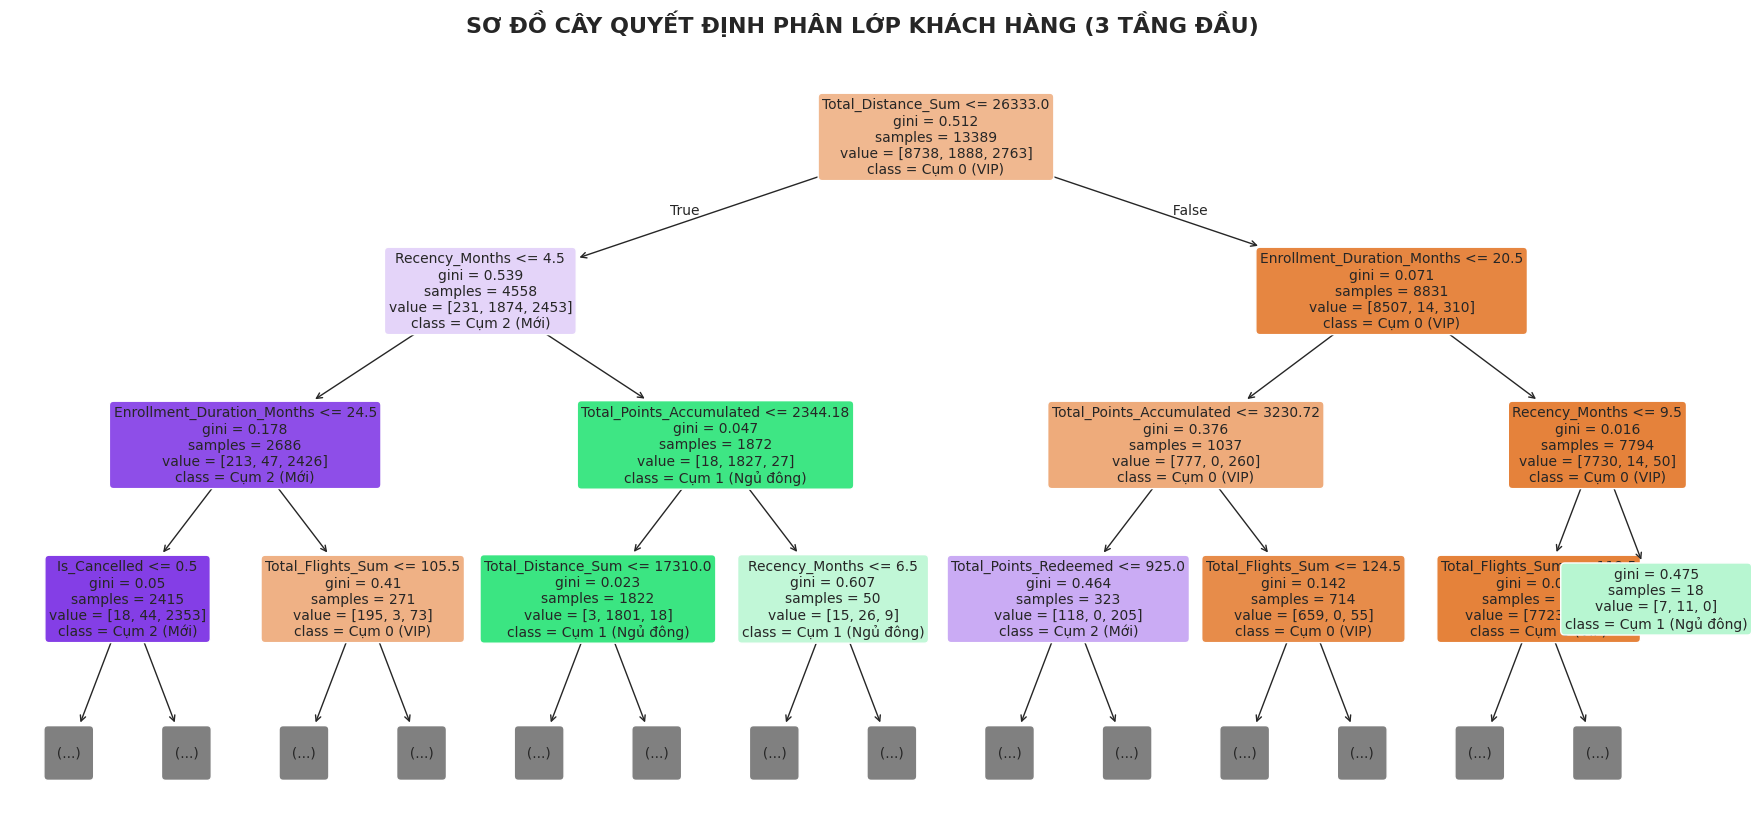

In [ ]:
# ==========================================
# 5.3.1 - TRỰC QUAN HÓA CÂY QUYẾT ĐỊNH (3 TẦNG ĐẦU)
# ==========================================
plt.figure(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=['Cụm 0 (VIP)', 'Cụm 1 (Ngủ đông)', 'Cụm 2 (Mới)'],
    filled=True, rounded=True, fontsize=10,
    max_depth=3  # Chỉ hiển thị 3 tầng đầu để dễ đọc
)
plt.title('SƠ ĐỒ CÂY QUYẾT ĐỊNH PHÂN LỚP KHÁCH HÀNG (3 TẦNG ĐẦU)',
          fontsize=16, fontweight='bold', pad=20)
plt.show()

In [ ]:
from sklearn.tree import export_text

rules = export_text(best_dt,
                    feature_names=features_for_clustering)
print("=== LUẬT PHÂN LỚP CỦA CÂY QUYẾT ĐỊNH ===")
print(rules)

=== LUẬT PHÂN LỚP CỦA CÂY QUYẾT ĐỊNH ===
|--- Total_Distance_Sum <= 26333.00
|   |--- Recency_Months <= 4.50
|   |   |--- Enrollment_Duration_Months <= 24.50
|   |   |   |--- Is_Cancelled <= 0.50
|   |   |   |   |--- Total_Points_Redeemed <= 1548.50
|   |   |   |   |   |--- Total_Flights_Sum <= 144.00
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- Total_Flights_Sum >  144.00
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |--- Total_Points_Redeemed >  1548.50
|   |   |   |   |   |--- Total_Points_Accumulated <= 2447.44
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- Total_Points_Accumulated >  2447.44
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- Is_Cancelled >  0.50
|   |   |   |   |--- Total_Distance_Sum <= 11158.00
|   |   |   |   |   |--- Recency_Months <= 1.50
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |   |--- Recency_Months >  1.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Total_Distance_Sum >  11158.00
| 

MỨC ĐỘ QUAN TRỌNG CỦA CÁC BIẾN SỐ:


,Feature,Importance,Importance (%)
3,Total_Distance_Sum,0.5792,57.9210
1,Recency_Months,0.2933,29.3271
0,Enrollment_Duration_Months,0.0600,5.9961
4,Total_Points_Accumulated,0.0274,2.7423
5,Total_Points_Redeemed,0.0229,2.2885
2,Total_Flights_Sum,0.0116,1.1583
6,Is_Cancelled,0.0057,0.5667
7,Salary,0.0000,0.0000


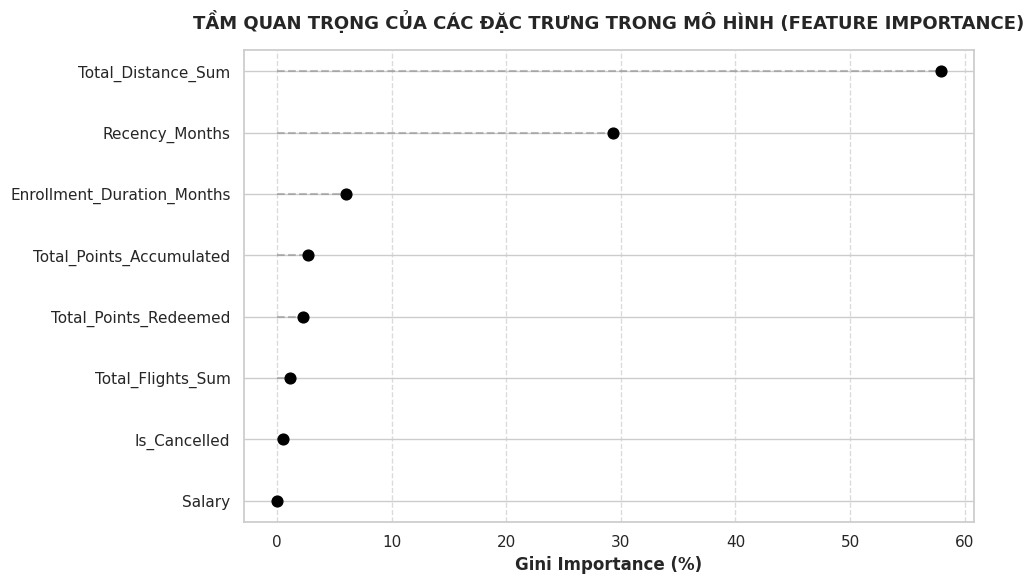

In [ ]:
# ==========================================
# 5.3.2 - MỨC ĐỘ QUAN TRỌNG CỦA CÁC BIẾN (FEATURE IMPORTANCE)
# ==========================================
importances = best_dt.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances,
    'Importance (%)': importances * 100
}).sort_values(by='Importance', ascending=False)

print("MỨC ĐỘ QUAN TRỌNG CỦA CÁC BIẾN SỐ:")
display(feature_importance_df.round(4))

# Vẽ biểu đồ Feature Importance (Scatter kiểu Lollipop ngang)
df_imp_sorted = feature_importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.hlines(y=df_imp_sorted['Feature'], xmin=0, xmax=df_imp_sorted['Importance'] * 100,
           color='gray', linestyle='--', alpha=0.5)
plt.scatter(df_imp_sorted['Importance'] * 100, df_imp_sorted['Feature'],
            color='black', s=60, zorder=3)
plt.xlabel('Gini Importance (%)', fontsize=12, fontweight='bold')
plt.title('TẦM QUAN TRỌNG CỦA CÁC ĐẶC TRƯNG TRONG MÔ HÌNH (FEATURE IMPORTANCE)',
          fontsize=13, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5.4 - DỰ ĐOÁN KHÁCH HÀNG MỚI (VÍ DỤ THỰC TẾ)
# ==========================================
print(">> MỤC 5.4.2: VÍ DỤ MINH HỌA DỰ ĐOÁN KHÁCH HÀNG MỚI <<")
print("-" * 60)

new_customers = pd.DataFrame({
    'Enrollment_Duration_Months': [50,  5],
    'Recency_Months':             [1,   2],
    'Total_Flights_Sum':          [150, 10],
    'Total_Distance_Sum':         [40000, 2000],
    'Total_Points_Accumulated':   [4500, 200],
    'Total_Points_Redeemed':      [0,   0],
    'Is_Cancelled':               [0,   0],
    'Salary':                     [100000, 50000]
})

# Đảm bảo thứ tự cột khớp với X_train
new_customers = new_customers[X.columns.tolist()]

print("Thông tin 2 khách hàng giả định:")
display(new_customers)

predictions = best_dt.predict(new_customers)
cluster_dict = {
    0: 'Cụm 0 (Khách VIP/Trung thành)',
    1: 'Cụm 1 (Khách Ngủ đông/Rời bỏ)',
    2: 'Cụm 2 (Khách Mới/Tiềm năng)'
}
print("\nKẾT QUẢ DỰ ĐOÁN:")
for i, pred in enumerate(predictions):
    print(f"  - Khách hàng {i+1} được AI dự đoán thuộc: {cluster_dict[pred]}")
# In ra xác suất dự đoán từng cụm
proba = best_dt.predict_proba(new_customers)
proba_df = pd.DataFrame(proba,
                         columns=['Xác suất Cụm 0',
                                  'Xác suất Cụm 1',
                                  'Xác suất Cụm 2'])
proba_df['Dự đoán cuối'] = best_dt.predict(new_customers)
display(proba_df)

>> MỤC 5.4.2: VÍ DỤ MINH HỌA DỰ ĐOÁN KHÁCH HÀNG MỚI <<
------------------------------------------------------------
Thông tin 2 khách hàng giả định:


,Enrollment_Duration_Months,Recency_Months,Total_Flights_Sum,Total_Distance_Sum,Total_Points_Accumulated,Total_Points_Redeemed,Is_Cancelled,Salary
0,50,1,150,40000,4500,0,0,100000
1,5,2,10,2000,200,0,0,50000



KẾT QUẢ DỰ ĐOÁN:
  - Khách hàng 1 được AI dự đoán thuộc: Cụm 0 (Khách VIP/Trung thành)
  - Khách hàng 2 được AI dự đoán thuộc: Cụm 2 (Khách Mới/Tiềm năng)


,Xác suất Cụm 0,Xác suất Cụm 1,Xác suất Cụm 2,Dự đoán cuối
0,0.999855,0.0,0.000145,0
1,0.001813,0.0,0.998187,2


---
# CHƯƠNG 6: KIỂM ĐỊNH THỐNG KÊ

In [ ]:
# ==========================================
# IMPORT THƯ VIỆN KIỂM ĐỊNH
# ==========================================
import scipy.stats as stats
import itertools

# 5 biến cốt lõi LRFMC để kiểm định
cols_to_test = [
    'Enrollment_Duration_Months',   # L
    'Recency_Months',               # R
    'Total_Flights_Sum',            # F
    'Total_Points_Accumulated',     # M
    'Is_Cancelled'                  # C
]

In [ ]:
# ==========================================
# 6.1. KIỂM ĐỊNH PHÂN PHỐI CHUẨN (SHAPIRO-WILK)
# ==========================================
print(">> 6.1. KIỂM ĐỊNH PHÂN PHỐI CHUẨN (SHAPIRO-WILK) <<")
print("-" * 60)
print("H0: Biến tuân theo phân phối chuẩn (Gaussian)")
print("H1: Biến KHÔNG tuân theo phân phối chuẩn")
print("-" * 60)

# Rút ngẫu nhiên 5000 mẫu (Shapiro-Wilk yêu cầu n ≤ 5000)
np.random.seed(42)
sample_df = df_final.sample(n=5000, random_state=42)

for col in cols_to_test:
    stat, p = stats.shapiro(sample_df[col])
    conclusion = "CÓ phân phối chuẩn." if p > 0.05 else "KHÔNG có phân phối chuẩn."
    print(f"Biến [{col}]:")
    print(f"  Statistic = {stat:.4f} | p-value = {p:.4e}")
    print(f"  => {conclusion}")
    print()

print("\nKẾT LUẬN: Dữ liệu KHÔNG tuân theo phân phối chuẩn")
print("=> Sử dụng kiểm định PHI THAM SỐ: Kruskal-Wallis & Mann-Whitney U.")

>> 6.1. KIỂM ĐỊNH PHÂN PHỐI CHUẨN (SHAPIRO-WILK) <<
------------------------------------------------------------
H0: Biến tuân theo phân phối chuẩn (Gaussian)
H1: Biến KHÔNG tuân theo phân phối chuẩn
------------------------------------------------------------
Biến [Enrollment_Duration_Months]:
  Statistic = 0.9458 | p-value = 1.7927e-39
  => KHÔNG có phân phối chuẩn.

Biến [Recency_Months]:
  Statistic = 0.4803 | p-value = 5.5031e-81
  => KHÔNG có phân phối chuẩn.

Biến [Total_Flights_Sum]:
  Statistic = 0.9102 | p-value = 2.0309e-47
  => KHÔNG có phân phối chuẩn.

Biến [Total_Points_Accumulated]:
  Statistic = 0.8966 | p-value = 8.9788e-50
  => KHÔNG có phân phối chuẩn.

Biến [Is_Cancelled]:
  Statistic = 0.3775 | p-value = 5.8692e-85
  => KHÔNG có phân phối chuẩn.


KẾT LUẬN: Dữ liệu KHÔNG tuân theo phân phối chuẩn
=> Sử dụng kiểm định PHI THAM SỐ: Kruskal-Wallis & Mann-Whitney U.


In [ ]:
# ==========================================
# 6.2. KIỂM ĐỊNH SỰ KHÁC BIỆT GIỮA CÁC CỤM (KRUSKAL-WALLIS)
# ==========================================
print(">> 6.2. KIỂM ĐỊNH KRUSKAL-WALLIS (THAY THẾ PHI THAM SỐ CỦA ANOVA) <<")
print("-" * 60)
print("H0: Trung vị của biến KHÔNG khác biệt giữa 3 cụm")
print("H1: Có ít nhất 1 cụm có trung vị khác biệt đáng kể")
print("-" * 60)

group0 = df_final[df_final['Cluster'] == 0]
group1 = df_final[df_final['Cluster'] == 1]
group2 = df_final[df_final['Cluster'] == 2]

for col in cols_to_test:
    stat, p = stats.kruskal(group0[col], group1[col], group2[col])
    conclusion = "CÓ SỰ KHÁC BIỆT có ý nghĩa thống kê." if p < 0.05 else "KHÔNG có sự khác biệt."
    print(f"Biến [{col}]:")
    print(f"  Kruskal Stat = {stat:.4f} | p-value = {p:.4e}")
    print(f"  => {conclusion}")
    print()

>> 6.2. KIỂM ĐỊNH KRUSKAL-WALLIS (THAY THẾ PHI THAM SỐ CỦA ANOVA) <<
------------------------------------------------------------
H0: Trung vị của biến KHÔNG khác biệt giữa 3 cụm
H1: Có ít nhất 1 cụm có trung vị khác biệt đáng kể
------------------------------------------------------------
Biến [Enrollment_Duration_Months]:
  Kruskal Stat = 6454.9503 | p-value = 0.0000e+00
  => CÓ SỰ KHÁC BIỆT có ý nghĩa thống kê.

Biến [Recency_Months]:
  Kruskal Stat = 7610.2845 | p-value = 0.0000e+00
  => CÓ SỰ KHÁC BIỆT có ý nghĩa thống kê.

Biến [Total_Flights_Sum]:
  Kruskal Stat = 11217.0320 | p-value = 0.0000e+00
  => CÓ SỰ KHÁC BIỆT có ý nghĩa thống kê.

Biến [Total_Points_Accumulated]:
  Kruskal Stat = 11330.6013 | p-value = 0.0000e+00
  => CÓ SỰ KHÁC BIỆT có ý nghĩa thống kê.

Biến [Is_Cancelled]:
  Kruskal Stat = 9912.6942 | p-value = 0.0000e+00
  => CÓ SỰ KHÁC BIỆT có ý nghĩa thống kê.



In [ ]:
# ==========================================
# 6.3. KIỂM ĐỊNH HẬU NGHIỆM TỪNG CẶP CỤM (MANN-WHITNEY U + BONFERRONI)
# ==========================================
print(">> 6.3. KIỂM ĐỊNH TỪNG CẶP (MANN-WHITNEY U CÓ HIỆU CHỈNH BONFERRONI) <<")
print("-" * 65)

clusters = [0, 1, 2]
pairs = list(itertools.combinations(clusters, 2))  # [(0,1), (0,2), (1,2)]

for col in cols_to_test:
    print(f"--- Biến: {col} ---")
    for (c1, c2) in pairs:
        data1 = df_final[df_final['Cluster'] == c1][col]
        data2 = df_final[df_final['Cluster'] == c2][col]

        stat, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')

        # Bonferroni correction: nhân p-value với số lượng cặp
        p_adj = min(p * len(pairs), 1.0)

        if p_adj < 0.05:
            print(f"  Cụm {c1} vs Cụm {c2}: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = {p_adj:.4e})")
        else:
            print(f"  Cụm {c1} vs Cụm {c2}: KHÔNG KHÁC BIỆT (p-adj = {p_adj:.4f})ℹ️")
    print()

>> 6.3. KIỂM ĐỊNH TỪNG CẶP (MANN-WHITNEY U CÓ HIỆU CHỈNH BONFERRONI) <<
-----------------------------------------------------------------
--- Biến: Enrollment_Duration_Months ---
  Cụm 0 vs Cụm 1: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 2.9603e-51)
  Cụm 0 vs Cụm 2: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)
  Cụm 1 vs Cụm 2: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)

--- Biến: Recency_Months ---
  Cụm 0 vs Cụm 1: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)
  Cụm 0 vs Cụm 2: KHÔNG KHÁC BIỆT (p-adj = 0.1596)ℹ️
  Cụm 1 vs Cụm 2: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)

--- Biến: Total_Flights_Sum ---
  Cụm 0 vs Cụm 1: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)
  Cụm 0 vs Cụm 2: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)
  Cụm 1 vs Cụm 2: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)

--- Biến: Total_Points_Accumulated ---
  Cụm 0 vs Cụm 1: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)
  Cụm 0 vs Cụm 2: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)
  Cụm 1 vs Cụm 2: KHÁC BIỆT CÓ Ý NGHĨA (p-adj = 0.0000e+00)

--- 

---
# CHƯƠNG 7 & 8: KẾT QUẢ, ĐỀ XUẤT CHIẾN LƯỢC CRM & KẾT LUẬN

## Tóm tắt kết quả 3 cụm

| Cụm | Tên gọi | Số KH | % | Đặc điểm chính | Đóng góp GT |
|-----|---------|-------|---|----------------|-------------|
| **0** | VIP / Trung thành | ~10,923 | 65.26% | Thâm niên cao (~47 th), bay nhiều (~164 chuyến), Recency thấp (~0.5 th), hủy thẻ 1% | **86.89%** |
| **1** | Rời bỏ / Ngủ đông | ~2,360 | 14.10% | Recency cao (~20 th), **hủy thẻ 75%**, giá trị cực thấp | 2.06% |
| **2** | Mới / Tiềm năng | ~3,454 | 20.64% | Thâm niên thấp (~10 th), đang hoạt động tốt, hủy thẻ 4% | 11.05% |

## Chiến lược CRM đề xuất
- **Cụm 0 (VIP):** Triển khai đặc quyền cá nhân hóa, fast-track, phòng chờ VIP, quà mốc kỷ niệm chuyến bay.
- **Cụm 2 (Tiềm năng):** Gamification "nhân đôi điểm", cross-sell combo du lịch với ngân hàng/booking.
- **Cụm 1 (Ngủ đông):** Trigger email tự động khi Recency > 5.5 tháng, gửi voucher Win-back 20%. Khảo sát nếu đã hủy thẻ.

## Kết luận mô hình
- **K-Means (K=3):** DBI=1.01, Silhouette=0.37 → Phân cụm rõ nét và có ý nghĩa thống kê (Kruskal-Wallis, p≈0).
- **Decision Tree:** Accuracy=**97.85%** trên tập Test, không Overfitting.
- **Feature Importance:** `Total_Distance_Sum` (57.92%) + `Recency_Months` (29.33%) chiếm **87%** sức mạnh dự đoán. `Salary` = 0% → Hành vi quan trọng hơn nhân khẩu học.